**Student:** Aimen A Ali Etorki

**Student Number: 30095294**

**Year:** Feb 2025 Intake

**Supervisor:** Dr Mabrouka Abuhmida

**MSc Project:** CS4T702_2025/26 Artificial Intelligence 

**Project Title:**  Explainable Hybrid AI Model for Early Detection of Alzheimer’s Disease Using MRI-Derived Hippocampal and Brain Structural Features

# Notebook 5: Explainable Hybrid AI Model Development and Evaluation

## Objective

This notebook develops and evaluates an explainable hybrid AI framework for multiclass classification of Alzheimer's disease using the ADNI dataset prepared in Notebook 4. The classification task distinguishes between cognitively normal (CN), mild cognitive impairment (MCI), and Alzheimer's disease (AD) participants.

The modelling framework combines MRI-derived structural biomarkers with deep representations learned directly from preprocessed structural MRI slices. Model performance is evaluated using participant-level methods to ensure that predictions from multiple MRI slices belonging to the same participant do not artificially inflate the reported results.

## Modelling Branches

Three complementary modelling branches are developed:

1. **Traditional Machine Learning** — Logistic Regression, Support Vector Machine (SVM), Random Forest, and XGBoost are trained using MRI-derived hippocampal and structural biomarkers.

2. **Deep Learning** — A ResNet-18 convolutional neural network is fine-tuned using preprocessed 224 × 224 coronal MRI slices to learn image-based representations associated with CN, MCI, and AD.

3. **Hybrid AI** — Deep features extracted from the ResNet-18 model are combined with MRI-derived structural biomarkers to integrate image-based and anatomically interpretable information within a single classification framework.

## Methodological Considerations

The modelling and evaluation pipeline incorporates several measures to improve reliability, reproducibility, and interpretability:

* **Participant-level data separation.** Training, validation, and test sets are separated at participant level so that MRI slices from the same participant cannot appear across different data splits.

* **Participant-level evaluation.** Each participant contributes multiple MRI slices. Deep-learning predictions are therefore aggregated at participant level for the primary evaluation, reducing the risk of inflated performance caused by treating correlated slices as independent observations.

* **Overfitting control.** Data augmentation, partial layer freezing, dropout, weight decay, class weighting, label smoothing, learning-rate scheduling, and early stopping are incorporated into ResNet-18 training.

* **Class imbalance awareness.** Class distributions are examined throughout the modelling pipeline, and a majority-class baseline is reported to provide context for interpreting classification performance.

* **Multiple evaluation metrics.** Model performance is assessed using accuracy, balanced accuracy, precision, recall, F1-score, Matthews correlation coefficient (MCC), confusion matrices, and multiclass ROC-AUC where appropriate. This provides a more informative evaluation than accuracy alone, particularly in the presence of class imbalance.

* **Intracranial volume normalisation.** Regional volumetric biomarkers are normalised by intracranial volume (ICV) to reduce the influence of individual differences in overall head size.

* **Reproducibility.** Random seeds are controlled across Python, NumPy, scikit-learn, PyTorch, and CUDA where applicable. Additional multi-seed analysis is used to examine the stability of CNN-dependent results across different random initialisations.

* **Transparent model comparison.** The evaluation protocol and number of participants used for each modelling branch are reported explicitly. Models evaluated under different protocols are not treated as directly equivalent solely on the basis of their performance scores.

* **Explainability.** SHAP is used to examine the contribution of structural biomarkers, while Grad-CAM++ is used to visualise image regions influencing ResNet-18 predictions. Explainability analysis is used alongside predictive performance to assess the clinical interpretability of the modelling framework.


In [1]:
# ============================================================
# Core Libraries
# ============================================================

from pathlib import Path
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Core libraries imported successfully.")

Core libraries imported successfully.


In [2]:
# ============================================================
# Project Configuration
# ============================================================

def find_project_root(marker_folders=("MRI 1.5T & 3T Dataset", "notebooks")):
    """Walk upwards until a folder containing the project markers is found."""

    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if any((candidate / m).exists() for m in marker_folders):
            return candidate

    return Path(r"C:\Users\aimen\Documents\GitHub\MSc-Final-Project")


PROJECT_ROOT = find_project_root()


FINAL_DATASET_FOLDER = PROJECT_ROOT / "final_dataset"
BIOMARKER_FOLDER = PROJECT_ROOT / "biomarkers"

MODELS_FOLDER = PROJECT_ROOT / "models"
RESULTS_FOLDER = PROJECT_ROOT / "results"

MODELS_FOLDER.mkdir(parents=True, exist_ok=True)
RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)

# Source files actually used downstream.
# Note: the UCSFFSX7 table explored in the original notebook is
# not loaded here because none of its columns reach the final
# feature set - hippocampal volumes come from UCSFSNTVOL and the
# remaining structural measures come from MUSE.

SNT_FILE = BIOMARKER_FOLDER / "UCSFSNTVOL_12Aug2026.csv"
MUSE_FILE = BIOMARKER_FOLDER / "MUSE_volume_ADNI123_13Aug2026.csv"
METADATA_FILE = PROJECT_ROOT / "MRI_1.5T___3T_Dataset_7_08_2026.csv"

CLASS_NAMES = ["CN", "MCI", "AD"]
LABEL_MAP = {"CN": 0, "MCI": 1, "AD": 2}

print("Path check")
print("-" * 40)
for label, path in [
    ("Project root  ", PROJECT_ROOT),
    ("Final dataset ", FINAL_DATASET_FOLDER),
    ("SNT file      ", SNT_FILE),
    ("MUSE file     ", MUSE_FILE),
    ("Metadata file ", METADATA_FILE),
]:
    print(f"{label}: {path.exists()}")

Path check
----------------------------------------
Project root  : True
Final dataset : True
SNT file      : True
MUSE file     : True
Metadata file : True


## 5.1 Load the Final MRI Dataset

The training, validation, and test datasets created in Notebook 4 are loaded together with their participant identifiers and diagnostic labels. The participant-level split established in Notebook 4 is preserved throughout this notebook to prevent data leakage between the training, validation, and test sets and to support subsequent matching with MRI-derived structural biomarkers.


In [3]:
# ============================================================
# Load MRI Slices, Labels and Participant IDs
# ============================================================

X_train = np.load(FINAL_DATASET_FOLDER / "X_train.npy")
X_validation = np.load(FINAL_DATASET_FOLDER / "X_validation.npy")
X_test = np.load(FINAL_DATASET_FOLDER / "X_test.npy")

y_train = np.load(FINAL_DATASET_FOLDER / "y_train.npy", allow_pickle=True)
y_validation = np.load(FINAL_DATASET_FOLDER / "y_validation.npy", allow_pickle=True)
y_test = np.load(FINAL_DATASET_FOLDER / "y_test.npy", allow_pickle=True)

train_ids = np.load(FINAL_DATASET_FOLDER / "train_ids.npy", allow_pickle=True)
validation_ids = np.load(FINAL_DATASET_FOLDER / "validation_ids.npy", allow_pickle=True)
test_ids = np.load(FINAL_DATASET_FOLDER / "test_ids.npy", allow_pickle=True)

print("TRAINING   :", X_train.shape, "|", len(np.unique(train_ids)), "participants")
print("VALIDATION :", X_validation.shape, "|", len(np.unique(validation_ids)), "participants")
print("TEST       :", X_test.shape, "|", len(np.unique(test_ids)), "participants")

print("\nSlices per participant (train):",
      round(len(X_train) / len(np.unique(train_ids)), 1))

TRAINING   : (5740, 224, 224) | 287 participants
VALIDATION : (1240, 224, 224) | 62 participants
TEST       : (1240, 224, 224) | 62 participants

Slices per participant (train): 20.0


In [4]:
# ============================================================
# Verify Participant-Level Separation
# ============================================================

train_participants = set(np.unique(train_ids))
validation_participants = set(np.unique(validation_ids))
test_participants = set(np.unique(test_ids))

assert train_participants.isdisjoint(validation_participants)
assert train_participants.isdisjoint(test_participants)
assert validation_participants.isdisjoint(test_participants)

print("No participant overlap between splits.")

# ------------------------------------------------------------
# Class balance per split
#
# The majority-class baseline provides a reference point for
# interpreting classification accuracy within each split.
# ------------------------------------------------------------

for split_name, labels in [
    ("Train", y_train),
    ("Validation", y_validation),
    ("Test", y_test),
]:
    counts = pd.Series(labels).value_counts()
    majority = counts.max() / counts.sum()
    print(f"\n{split_name} slice distribution:")
    print(counts.to_string())
    print(f"Majority-class baseline: {majority:.4f}")

No participant overlap between splits.

Train slice distribution:
MCI    2800
CN     1640
AD     1300
Majority-class baseline: 0.4878

Validation slice distribution:
MCI    620
CN     340
AD     280
Majority-class baseline: 0.5000

Test slice distribution:
MCI    600
CN     360
AD     280
Majority-class baseline: 0.4839


## 5.2 Build the Structural Biomarker Dataset

Hippocampal volumes are obtained from the UCSFSNTVOL dataset, while the remaining structural brain measures are obtained from MUSE. Biomarker records are matched to the corresponding participant MRI session using acquisition dates, with the temporally closest available record selected for each participant.

A maximum matching tolerance of 45 days is applied to limit temporal differences between the MRI acquisition and the associated biomarker measurements. Matches exceeding this tolerance are excluded from the structural biomarker dataset.


In [5]:
# ============================================================
# Load Source Tables
# ============================================================

hippocampus = pd.read_csv(SNT_FILE, low_memory=False)
muse = pd.read_csv(MUSE_FILE, low_memory=False)
metadata = pd.read_csv(METADATA_FILE, low_memory=False)

print("SNT hippocampal :", hippocampus.shape)
print("MUSE volumetric :", muse.shape)
print("MRI metadata    :", metadata.shape)

SNT hippocampal : (1874, 15)
MUSE volumetric : (10329, 273)
MRI metadata    : (520, 12)


In [6]:

# ============================================================
# Matching Tolerance
#
# Biomarker records are matched to MRI sessions using acquisition
# dates. A maximum tolerance of 45 days is allowed to account for
# small differences between the MRI acquisition date and the
# corresponding biomarker assessment date.
#
# Records outside this window are excluded to reduce temporal
# mismatch between the imaging data and structural measurements.
# A 30-day sensitivity check is performed later to assess how a
# stricter matching window affects the available cohort size.
# ============================================================


MATCH_TOLERANCE_DAYS = 45

In [8]:
# ============================================================
# Prepare Metadata for Matching
# ============================================================

metadata["RID"] = (
    metadata["Subject"].str.split("_").str[-1].astype(int)
)

metadata["Acq Date"] = pd.to_datetime(metadata["Acq Date"])

# One MRI session per Subject/Visit
metadata_clean = (
    metadata
    .drop_duplicates(subset=["Subject", "Visit"], keep="first")
    .copy()
)

hippocampus["EXAMDATE"] = pd.to_datetime(hippocampus["EXAMDATE"])

muse_selected = muse[[
    "PTID",
    "EXAMDATE",
    "VENTRICLE",
    "WM",
    "ICV",
    "Left_Ent_entorhinal_area",
    "Right_Ent_entorhinal_area",
]].copy()

muse_selected["EXAMDATE"] = pd.to_datetime(muse_selected["EXAMDATE"])

print("MRI sessions after de-duplication :", len(metadata_clean))
print("Unique subjects                   :", metadata_clean["Subject"].nunique())

MRI sessions after de-duplication : 460
Unique subjects                   : 411


In [9]:
# ============================================================
# Nearest-Date Matching
#
# Each MRI session is matched to the temporally closest
# hippocampal and MUSE biomarker record for the same participant
# using vectorised nearest-date matching.
#
# Participant identifiers are retained directly through the merge
# so that MRI sessions and biomarker measurements remain correctly
# aligned even when rows with missing dates or identifiers are
# excluded.
# ============================================================

def match_nearest(mri_frame, source_frame, join_key,
                  value_columns, diff_name):
    """
    Match each MRI session to the temporally closest record in
    source_frame for the same participant.

    join_key must exist in both frames. "Subject" and "Acq Date"
    must exist in mri_frame; "EXAMDATE" must exist in source_frame.
    """

    left = (
        mri_frame[["Subject", join_key, "Acq Date"]]
        .dropna(subset=[join_key, "Acq Date"])
        .sort_values("Acq Date")
        .reset_index(drop=True)
    )

    right = (
        source_frame[[join_key, "EXAMDATE"] + value_columns]
        .dropna(subset=[join_key, "EXAMDATE"])
        .sort_values("EXAMDATE")
        .reset_index(drop=True)
    )

    merged = pd.merge_asof(
        left,
        right,
        left_on="Acq Date",
        right_on="EXAMDATE",
        by=join_key,
        direction="nearest",
    )

    merged[diff_name] = (
        merged["EXAMDATE"] - merged["Acq Date"]
    ).abs().dt.days

    # Row count must be preserved by merge_asof
    assert len(merged) == len(left), "merge_asof changed row count"

    return merged


# ---- hippocampal volumes (matched on RID) ----
hippo_matched = match_nearest(
    metadata_clean,
    hippocampus,
    join_key="RID",
    value_columns=["LEFTHIPPO", "RIGHTHIPPO"],
    diff_name="HIPPO_DATE_DIFF",
)

# ---- MUSE volumes (matched on PTID, which equals Subject) ----
muse_matched = match_nearest(
    metadata_clean.assign(PTID=metadata_clean["Subject"]),
    muse_selected,
    join_key="PTID",
    value_columns=[
        "VENTRICLE", "WM", "ICV",
        "Left_Ent_entorhinal_area",
        "Right_Ent_entorhinal_area",
    ],
    diff_name="MUSE_DATE_DIFF",
)

print("MRI sessions considered :", len(metadata_clean))
print("Hippocampal matches     :", hippo_matched["LEFTHIPPO"].notna().sum())
print("MUSE matches            :", muse_matched["ICV"].notna().sum())

MRI sessions considered : 460
Hippocampal matches     : 332
MUSE matches            : 455


In [10]:
# ============================================================
# Apply Tolerance and Merge
# ============================================================

hippo_final = hippo_matched[
    hippo_matched["HIPPO_DATE_DIFF"] <= MATCH_TOLERANCE_DAYS
][["Subject", "LEFTHIPPO", "RIGHTHIPPO", "HIPPO_DATE_DIFF"]].drop_duplicates("Subject")

muse_final = muse_matched[
    muse_matched["MUSE_DATE_DIFF"] <= MATCH_TOLERANCE_DAYS
][[
    "Subject", "VENTRICLE", "WM", "ICV",
    "Left_Ent_entorhinal_area", "Right_Ent_entorhinal_area",
    "MUSE_DATE_DIFF",
]].drop_duplicates("Subject")

biomarker_dataset = hippo_final.merge(
    muse_final, on="Subject", how="inner"
)

biomarker_dataset = biomarker_dataset.rename(columns={
    "Left_Ent_entorhinal_area": "LEFT_ENTORHINAL",
    "Right_Ent_entorhinal_area": "RIGHT_ENTORHINAL",
})

# Attach diagnosis
diagnosis = (
    metadata_clean[["Subject", "Group"]]
    .drop_duplicates(subset="Subject")
)

biomarker_dataset = biomarker_dataset.merge(
    diagnosis, on="Subject", how="inner"
)

print(f"Participants at <= {MATCH_TOLERANCE_DAYS} days:",
      len(biomarker_dataset))

print("\nSensitivity check at 30 days:")
print("  hippocampal matches:",
      (hippo_matched["HIPPO_DATE_DIFF"] <= 30).sum())
print("  MUSE matches       :",
      (muse_matched["MUSE_DATE_DIFF"] <= 30).sum())

print("\nClass distribution:")
print(biomarker_dataset["Group"].value_counts().to_string())

Participants at <= 45 days: 260

Sensitivity check at 30 days:
  hippocampal matches: 303
  MUSE matches       : 414

Class distribution:
Group
MCI    130
CN      77
AD      53


### 5.2.1 Feature Engineering

The structural biomarker dataset is extended with derived features designed to account for differences in overall head size and to capture relationships between bilateral hippocampal measurements.

**Intracranial volume normalisation.** Regional brain volumes are influenced by individual differences in overall head size. To reduce this effect, volumetric biomarkers are normalised by intracranial volume (ICV) and expressed as proportions of ICV. ICV is also retained as a separate feature to preserve information related to overall intracranial size.

**Hippocampal asymmetry.** Differences between the left and right hippocampal volumes are represented using both signed and absolute asymmetry measures. The signed measure preserves the direction of hemispheric asymmetry, while the absolute measure captures its magnitude regardless of which hemisphere has the smaller volume.


In [11]:
# ============================================================
# Feature Engineering
# ============================================================

bd = biomarker_dataset

# ---- absolute volumes ----
bd["TOTAL_HIPPO"] = bd["LEFTHIPPO"] + bd["RIGHTHIPPO"]
bd["TOTAL_ENTORHINAL"] = bd["LEFT_ENTORHINAL"] + bd["RIGHT_ENTORHINAL"]

# ---- ICV-normalised volumes (per 1000 for readable scale) ----
for column in ["LEFTHIPPO", "RIGHTHIPPO", "TOTAL_HIPPO",
               "TOTAL_ENTORHINAL", "VENTRICLE", "WM"]:
    bd[f"{column}_ICV"] = bd[column] / bd["ICV"] * 1000.0

# ---- hippocampal asymmetry ----
# Signed: negative indicates a smaller left hippocampus, the
# pattern more commonly reported in early Alzheimer's disease.
bd["HIPPO_ASYM_SIGNED"] = (
    (bd["LEFTHIPPO"] - bd["RIGHTHIPPO"])
    / bd["TOTAL_HIPPO"]
)

bd["HIPPO_ASYM_ABS"] = bd["HIPPO_ASYM_SIGNED"].abs()

FEATURE_COLUMNS = [
    "LEFTHIPPO_ICV",
    "RIGHTHIPPO_ICV",
    "TOTAL_HIPPO_ICV",
    "HIPPO_ASYM_SIGNED",
    "HIPPO_ASYM_ABS",
    "TOTAL_ENTORHINAL_ICV",
    "VENTRICLE_ICV",
    "WM_ICV",
    "ICV",
]

FEATURE_DISPLAY_NAMES = [
    "Left Hippocampus (/ICV)",
    "Right Hippocampus (/ICV)",
    "Total Hippocampus (/ICV)",
    "Hippocampal Asymmetry (signed)",
    "Hippocampal Asymmetry (absolute)",
    "Total Entorhinal Cortex (/ICV)",
    "Ventricular Volume (/ICV)",
    "White Matter Volume (/ICV)",
    "Intracranial Volume",
]

X_ml = bd[FEATURE_COLUMNS].copy()
y_ml = bd["Group"].map(LABEL_MAP)
subjects_ml = bd["Subject"].values

assert X_ml.isnull().sum().sum() == 0, "Missing values in feature matrix"
assert y_ml.isnull().sum() == 0, "Unmapped diagnosis labels"

print("Feature matrix :", X_ml.shape)
print("Labels         :", y_ml.shape)
print("\nClass distribution:")
print(y_ml.map({v: k for k, v in LABEL_MAP.items()}).value_counts().to_string())

majority_baseline_ml = y_ml.value_counts().max() / len(y_ml)
print(f"\nMajority-class baseline: {majority_baseline_ml:.4f}")

display(X_ml.describe().T.round(4))

Feature matrix : (260, 9)
Labels         : (260,)

Class distribution:
Group
MCI    130
CN      77
AD      53

Majority-class baseline: 0.5000


,count,mean,std,min,25%,50%,75%,max
LEFTHIPPO_ICV,260.0,9.151000e-01,0.4847,0.2280,5.552000e-01,7.771000e-01,1.144800e+00,2.438500e+00
RIGHTHIPPO_ICV,260.0,9.414000e-01,0.5001,0.2624,5.774000e-01,7.795000e-01,1.138900e+00,2.339600e+00
TOTAL_HIPPO_ICV,260.0,1.856500e+00,0.9784,0.4945,1.126800e+00,1.566000e+00,2.249600e+00,4.689500e+00
HIPPO_ASYM_SIGNED,260.0,-1.260000e-02,0.0549,-0.1756,-4.750000e-02,-1.040000e-02,1.850000e-02,1.784000e-01
HIPPO_ASYM_ABS,260.0,4.320000e-02,0.0361,0.0001,1.500000e-02,3.580000e-02,6.150000e-02,1.784000e-01
TOTAL_ENTORHINAL_ICV,260.0,1.641500e+00,0.8476,0.2233,1.019900e+00,1.343100e+00,2.111600e+00,4.881700e+00
VENTRICLE_ICV,260.0,2.386730e+01,17.7338,5.5731,1.297690e+01,1.888930e+01,2.848660e+01,1.096528e+02
WM_ICV,260.0,2.455246e+02,116.0600,24.2401,1.607501e+02,2.112225e+02,2.955999e+02,5.955053e+02
ICV,260.0,2.395299e+06,979108.3115,648053.0000,1.599268e+06,2.369575e+06,3.045055e+06,5.272620e+06


## 5.3 Traditional Machine Learning Branch

Four traditional machine learning classifiers are evaluated using the MRI-derived structural biomarker features: Logistic Regression, Support Vector Machine (SVM), Random Forest, and XGBoost.

Model performance is assessed using **repeated stratified cross-validation**. Stratification preserves the diagnostic class distribution across folds, while repeated cross-validation provides a more robust estimate of model performance by evaluating each classifier across multiple train-test partitions. Performance variability across repetitions is also reported to assess the stability of the results.

All preprocessing operations that learn parameters from the data, including feature scaling, are performed **within the cross-validation pipeline**. This ensures that information from participants in each validation fold is not used during preprocessing of the corresponding training fold and therefore reduces the risk of data leakage.

Class imbalance is considered during model training, with class weighting applied to classifiers that support it. Model performance is evaluated using multiple metrics, including accuracy, balanced accuracy, macro F1-score, Matthews correlation coefficient (MCC), and multiclass ROC-AUC where appropriate.


In [15]:
# ============================================================
# Machine Learning Libraries
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_validate,
    cross_val_predict,
    StratifiedKFold,
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    matthews_corrcoef,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ------------------------------------------------------------
# Repeated stratified cross-validation
#
# Five folds are repeated five times, giving 25 train-validation
# evaluations per model. Repeating the stratified splits provides
# a more stable estimate of model performance and its variability
# across different participant partitions.
# ------------------------------------------------------------

N_SPLITS = 5
N_REPEATS = 5

cv_repeated = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_SEED,
)

# Single-pass CV used only for generating out-of-fold predictions
cv_single = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_SEED,
)

print(f"Cross-validation: {N_SPLITS}-fold x {N_REPEATS} repeats "
      f"= {N_SPLITS * N_REPEATS} fits per model")

Cross-validation: 5-fold x 5 repeats = 25 fits per model


In [16]:
# ============================================================
# ICV Confound Check
#
# Intracranial volume (ICV) may show apparent group differences
# that reflect demographic variation rather than disease-specific
# neurodegeneration. The distribution of ICV is therefore examined
# by diagnostic group and sex to assess whether sex imbalance may
# contribute to any observed association.
# ============================================================

demo = bd.merge(
    metadata[["Subject", "Sex", "Age"]].drop_duplicates("Subject"),
    on="Subject", how="left",
)

demo_binary = demo[demo["Group"].isin(["CN", "AD"])]

print("ICV by group and sex")
print("-" * 46)
print(demo_binary.groupby(["Group", "Sex"])["ICV"]
      .agg(["count", "mean", "std"]).round(0).to_string())

print("\nICV by group (pooled)")
print("-" * 46)
print(demo_binary.groupby("Group")["ICV"]
      .agg(["count", "mean", "std"]).round(0).to_string())

print("\nSex distribution")
print("-" * 46)
print(pd.crosstab(demo_binary["Group"], demo_binary["Sex"]).to_string())

ICV by group and sex
----------------------------------------------
           count       mean       std
Group Sex                            
AD    F       28  2450643.0  835130.0
      M       25  2677480.0  832133.0
CN    F       43  1935413.0  917327.0
      M       34  2246573.0  968375.0

ICV by group (pooled)
----------------------------------------------
       count       mean       std
Group                            
AD        53  2557642.0  833542.0
CN        77  2072808.0  946785.0

Sex distribution
----------------------------------------------
Sex     F   M
Group        
AD     28  25
CN     43  34


In [19]:
# ============================================================
# Effect of ICV Normalisation
#
# Volumetric biomarkers are compared before and after ICV
# normalisation to assess whether adjusting for overall
# intracranial size improves or reduces their ability to
# distinguish CN from AD.
#
# The coefficient of variation of ICV is also reported as a
# descriptive check on the variability of intracranial volume
# measurements within the biomarker cohort.
# ============================================================

from sklearn.metrics import roc_auc_score

pairs = [
    ("LEFTHIPPO", "LEFTHIPPO_ICV"),
    ("RIGHTHIPPO", "RIGHTHIPPO_ICV"),
    ("TOTAL_HIPPO", "TOTAL_HIPPO_ICV"),
    ("TOTAL_ENTORHINAL", "TOTAL_ENTORHINAL_ICV"),
    ("VENTRICLE", "VENTRICLE_ICV"),
    ("WM", "WM_ICV"),
]

binary_bd = bd[bd["Group"].isin(["CN", "AD"])]
y_bin = (binary_bd["Group"] == "AD").astype(int).values

rows = []
for raw, norm in pairs:
    auc_raw = roc_auc_score(y_bin, binary_bd[raw].values)
    auc_norm = roc_auc_score(y_bin, binary_bd[norm].values)
    rows.append({
        "Feature": raw,
        "AUC raw": max(auc_raw, 1 - auc_raw),
        "AUC /ICV": max(auc_norm, 1 - auc_norm),
        "Change": max(auc_norm, 1 - auc_norm) - max(auc_raw, 1 - auc_raw),
    })

comparison = pd.DataFrame(rows).round(4)
display(comparison)

print(f"Mean change from normalising: {comparison['Change'].mean():+.4f}")
print()
print(f"ICV coefficient of variation: "
      f"{bd['ICV'].std() / bd['ICV'].mean():.1%}  ")

,Feature,AUC raw,AUC /ICV,Change
0,LEFTHIPPO,0.8897,0.8045,-0.0853
1,RIGHTHIPPO,0.8829,0.8079,-0.0750
2,TOTAL_HIPPO,0.8954,0.8074,-0.0880
3,TOTAL_ENTORHINAL,0.7949,0.7366,-0.0583
4,VENTRICLE,0.6474,0.5033,-0.1441
5,WM,0.5293,0.6462,0.1169


Mean change from normalising: -0.0556

ICV coefficient of variation: 40.9%  


In [20]:
# ============================================================
# Evaluation Function
#
# Repeated stratified cross-validation is used to estimate the
# mean and standard deviation of the main performance metrics.
#
# A separate single stratified CV pass is used to generate
# out-of-fold participant predictions for MCC, classification
# reports, confusion matrices, and later paired comparisons.
# ============================================================

ml_predictions = {}


def evaluate_model(model, model_name, X, y,
                   cv=cv_repeated, show_plot=True):

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model),
    ])

    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "precision": "precision_macro",
        "recall": "recall_macro",
        "f1": "f1_macro",
    }

    scores = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    # Out-of-fold predictions from a single CV pass
    predictions = cross_val_predict(
        pipeline, X, y,
        cv=cv_single,
        n_jobs=-1,
    )

    ml_predictions[model_name] = predictions

    print("=" * 62)
    print(model_name)
    print("=" * 62)

    for metric_key, label in [
        ("accuracy", "Accuracy        "),
        ("balanced_accuracy", "Balanced Accuracy"),
        ("precision", "Precision (macro)"),
        ("recall", "Recall (macro)  "),
        ("f1", "F1 (macro)      "),
    ]:
        values = scores[f"test_{metric_key}"]
        print(f"{label}: {values.mean():.4f} +/- {values.std():.4f}")

    print(f"\nMajority-class baseline: {majority_baseline_ml:.4f}")
    print(f"MCC (out-of-fold)      : "
          f"{matthews_corrcoef(y, predictions):.4f}")

    print("\nClassification report (out-of-fold predictions)")
    print(classification_report(
        y, predictions,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        zero_division=0,
    ))

    if show_plot:
        cm = confusion_matrix(y, predictions, labels=[0, 1, 2])
        fig, ax = plt.subplots(figsize=(5, 5))
        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=CLASS_NAMES,
        ).plot(cmap="Blues", ax=ax, values_format="d")
        ax.set_title(model_name)
        plt.tight_layout()
        plt.show()

    return {
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),
        "Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "F1 SD": scores["test_f1"].std(),
        "MCC": matthews_corrcoef(y, predictions),
        "Protocol": f"{N_SPLITS}x{N_REPEATS} CV, n={len(y)} participants",
    }

Logistic Regression
Accuracy        : 0.5346 +/- 0.0639
Balanced Accuracy: 0.5715 +/- 0.0663
Precision (macro): 0.5452 +/- 0.0685
Recall (macro)  : 0.5715 +/- 0.0663
F1 (macro)      : 0.5361 +/- 0.0618

Majority-class baseline: 0.5000
MCC (out-of-fold)      : 0.2864

Classification report (out-of-fold predictions)
              precision    recall  f1-score   support

          CN       0.64      0.66      0.65        77
         MCI       0.59      0.39      0.47       130
          AD       0.34      0.60      0.44        53

    accuracy                           0.52       260
   macro avg       0.52      0.55      0.52       260
weighted avg       0.55      0.52      0.52       260



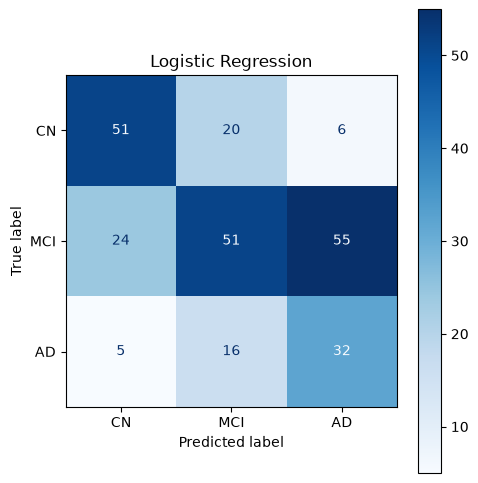

In [21]:
# ============================================================
# Logistic Regression
# ============================================================

logistic_results = evaluate_model(
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    "Logistic Regression",
    X_ml, y_ml,
)

Support Vector Machine
Accuracy        : 0.4785 +/- 0.0539
Balanced Accuracy: 0.5186 +/- 0.0609
Precision (macro): 0.5070 +/- 0.0632
Recall (macro)  : 0.5186 +/- 0.0609
F1 (macro)      : 0.4803 +/- 0.0561

Majority-class baseline: 0.5000
MCC (out-of-fold)      : 0.2300

Classification report (out-of-fold predictions)
              precision    recall  f1-score   support

          CN       0.60      0.57      0.59        77
         MCI       0.59      0.34      0.43       130
          AD       0.29      0.60      0.39        53

    accuracy                           0.46       260
   macro avg       0.49      0.50      0.47       260
weighted avg       0.53      0.46      0.47       260



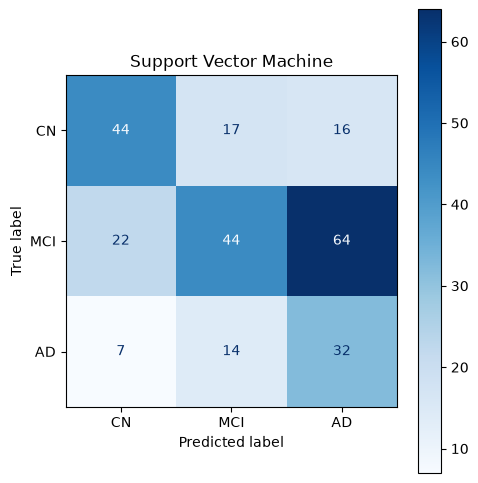

In [22]:
# ============================================================
# Support Vector Machine
# ============================================================

svm_results = evaluate_model(
    SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    "Support Vector Machine",
    X_ml, y_ml,
)

Random Forest
Accuracy        : 0.4446 +/- 0.0602
Balanced Accuracy: 0.4660 +/- 0.0661
Precision (macro): 0.4542 +/- 0.0640
Recall (macro)  : 0.4660 +/- 0.0661
F1 (macro)      : 0.4392 +/- 0.0603

Majority-class baseline: 0.5000
MCC (out-of-fold)      : 0.1248

Classification report (out-of-fold predictions)
              precision    recall  f1-score   support

          CN       0.52      0.53      0.53        77
         MCI       0.50      0.32      0.39       130
          AD       0.24      0.43      0.31        53

    accuracy                           0.41       260
   macro avg       0.42      0.43      0.41       260
weighted avg       0.45      0.41      0.41       260



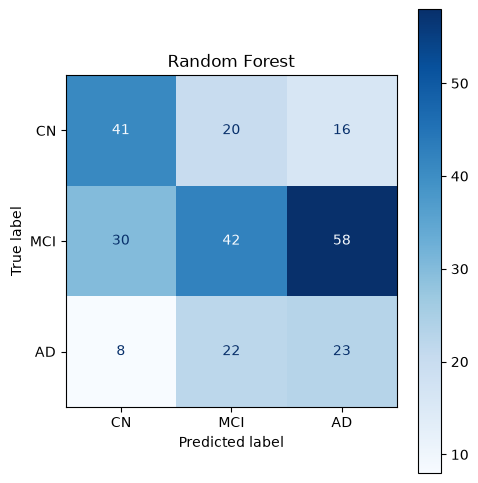

In [23]:
# ============================================================
# Random Forest
#
# Tree depth and minimum sample constraints are used to limit
# model complexity and reduce the risk of overfitting. Class
# weighting is applied to account for imbalance between the
# diagnostic groups.
# ============================================================

rf_results = evaluate_model(
    RandomForestClassifier(
        n_estimators=500,
        max_depth=4,
        min_samples_split=6,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "Random Forest",
    X_ml, y_ml,
)

XGBoost
Accuracy        : 0.5185 +/- 0.0567
Balanced Accuracy: 0.4408 +/- 0.0588
Precision (macro): 0.4629 +/- 0.0795
Recall (macro)  : 0.4408 +/- 0.0588
F1 (macro)      : 0.4375 +/- 0.0661

Majority-class baseline: 0.5000
MCC (out-of-fold)      : 0.1970

Classification report (out-of-fold predictions)
              precision    recall  f1-score   support

          CN       0.56      0.49      0.52        77
         MCI       0.55      0.70      0.62       130
          AD       0.29      0.15      0.20        53

    accuracy                           0.53       260
   macro avg       0.47      0.45      0.45       260
weighted avg       0.50      0.53      0.51       260



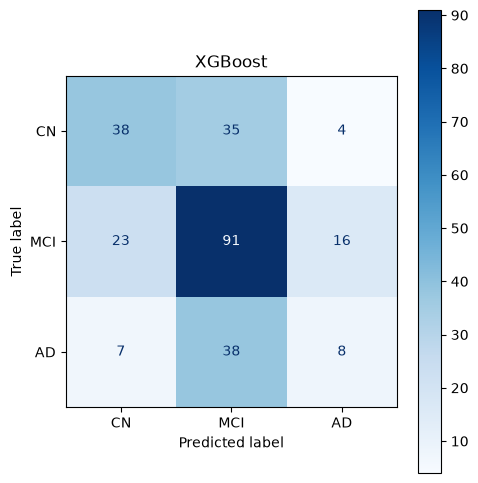

In [24]:
# ============================================================
# XGBoost
#
# Model complexity is controlled using shallow trees, shrinkage,
# subsampling, column sampling, and L1/L2 regularisation to reduce
# the risk of overfitting.
#
# num_class is omitted because the scikit-learn wrapper infers
# the number of classes directly from the target labels.
# ============================================================

xgb_params = dict(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2.0,
    min_child_weight=3,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_SEED,
)

xgb_results = evaluate_model(
    XGBClassifier(**xgb_params),
    "XGBoost",
    X_ml, y_ml,
)

In [26]:
# ============================================================
# Machine Learning Branch Summary
# ============================================================

ml_summary = pd.DataFrame([
    logistic_results, svm_results, rf_results, xgb_results
])

ml_display = ml_summary[[
    "Model", "Accuracy", "Accuracy SD",
    "Balanced Accuracy", "F1", "F1 SD", "MCC",
]].round(4).sort_values("MCC", ascending=False).reset_index(drop=True)

print("Machine learning branch")
print(f"Majority-class baseline: {majority_baseline_ml:.4f}\n")

display(ml_display)

print(
    "\nPerformance should be interpreted together with the variability "
    "reported across repeated cross-validation. Small differences "
    "between models should therefore be interpreted cautiously, "
    "particularly when performance varies across folds and repeats."
)

Machine learning branch
Majority-class baseline: 0.5000



,Model,Accuracy,Accuracy SD,Balanced Accuracy,F1,F1 SD,MCC
0,Logistic Regression,0.5346,0.0639,0.5715,0.5361,0.0618,0.2864
1,Support Vector Machine,0.4785,0.0539,0.5186,0.4803,0.0561,0.2300
2,XGBoost,0.5185,0.0567,0.4408,0.4375,0.0661,0.1970
3,Random Forest,0.4446,0.0602,0.4660,0.4392,0.0603,0.1248



Performance should be interpreted together with the variability reported across repeated cross-validation. Small differences between models should therefore be interpreted cautiously, particularly when performance varies across folds and repeats.


In [27]:
# ============================================================
# Supplementary: Binary CN vs AD Classification
#
# A supplementary binary classification analysis is performed
# using only CN and AD participants. Removing the intermediate
# MCI group provides a less complex classification task and
# allows the separability of the two diagnostic extremes to be
# examined independently from the primary three-class analysis.
#
# Binary and three-class results are reported separately because
# they represent different classification problems and should
# not be interpreted as directly equivalent.
# ============================================================


binary_mask = np.isin(np.asarray(y_ml),
                      [LABEL_MAP["CN"], LABEL_MAP["AD"]])

X_binary = X_ml[binary_mask]
y_binary = (np.asarray(y_ml)[binary_mask] == LABEL_MAP["AD"]).astype(int)

n_cn = int((y_binary == 0).sum())
n_ad = int((y_binary == 1).sum())
binary_baseline = max(n_cn, n_ad) / len(y_binary)

print(f"CN vs AD subset : {len(y_binary)} participants "
      f"({n_cn} CN, {n_ad} AD)")
print(f"Majority baseline: {binary_baseline:.4f}")
print(f"Three-class task for reference: {len(y_ml)} participants, "
      f"baseline {majority_baseline_ml:.4f}\n")

binary_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
    "Support Vector Machine": SVC(
        kernel="rbf", C=1.0, gamma="scale", class_weight="balanced",
        probability=True, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, max_depth=4, min_samples_split=6,
        min_samples_leaf=3, max_features="sqrt", class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=2, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        reg_lambda=2.0, min_child_weight=3,
        eval_metric="logloss", random_state=RANDOM_SEED),
}

binary_rows = []

for name, model in binary_models.items():

    pipeline = Pipeline([("scaler", StandardScaler()), ("model", model)])

    scores = cross_validate(
        pipeline, X_binary, y_binary, cv=cv_repeated,
        scoring={"accuracy": "accuracy",
                 "balanced_accuracy": "balanced_accuracy",
                 "roc_auc": "roc_auc"},
        n_jobs=-1)

    oof = cross_val_predict(pipeline, X_binary, y_binary,
                            cv=cv_single, n_jobs=-1)

    binary_rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),
        "Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "ROC-AUC SD": scores["test_roc_auc"].std(),
        "MCC": matthews_corrcoef(y_binary, oof),
    })

binary_results = (
    pd.DataFrame(binary_rows)
    .sort_values("MCC", ascending=False)
    .reset_index(drop=True)
)

print("=" * 70)
print("BINARY CN vs AD  (5x5 stratified CV)")
print("=" * 70)
display(binary_results.round(4))

best = binary_results.iloc[0]

print(f"Best binary model:{best['Model']}")
print(f"  Accuracy    : {best['Accuracy']:.4f} +/- {best['Accuracy SD']:.4f}")
print(f"  ROC-AUC     : {best['ROC-AUC']:.4f} +/- {best['ROC-AUC SD']:.4f}")
print(f"  vs baseline : {best['Accuracy'] - binary_baseline:+.4f}")

print()
print("Comparison of tasks")
print("-" * 52)
print(f"  Three-class CN/MCI/AD : MCC {logistic_results['MCC']:.4f}  "
      f"(n={len(y_ml)})")
print(f"  Binary CN vs AD       : MCC {best['MCC']:.4f}  "
      f"(n={len(y_binary)})")
print()
print("  The binary task excludes MCI, which is the class the")
print("  three-class models confuse most. The difference between")
print("  these numbers is a property of task difficulty, not of")
print("  model quality, and should be described as such.")

binary_results.to_csv(RESULTS_FOLDER / "binary_cn_vs_ad.csv", index=False)
print(f"\nSaved: {RESULTS_FOLDER / 'binary_cn_vs_ad.csv'}")

CN vs AD subset : 130 participants (77 CN, 53 AD)
Majority baseline: 0.5923
Three-class task for reference: 260 participants, baseline 0.5000

BINARY CN vs AD  (5x5 stratified CV)


,Model,Accuracy,Accuracy SD,Balanced Accuracy,ROC-AUC,ROC-AUC SD,MCC
0,Logistic Regression,0.7985,0.0716,0.8043,0.9058,0.0637,0.5737
1,Support Vector Machine,0.7308,0.0836,0.7426,0.8580,0.0697,0.4664
2,Random Forest,0.7123,0.0943,0.7184,0.8373,0.0658,0.4355
3,XGBoost,0.7462,0.0746,0.7348,0.8046,0.0714,0.3561


Best binary model:Logistic Regression
  Accuracy    : 0.7985 +/- 0.0716
  ROC-AUC     : 0.9058 +/- 0.0637
  vs baseline : +0.2062

Comparison of tasks
----------------------------------------------------
  Three-class CN/MCI/AD : MCC 0.2864  (n=260)
  Binary CN vs AD       : MCC 0.5737  (n=130)

  The binary task excludes MCI, which is the class the
  three-class models confuse most. The difference between
  these numbers is a property of task difficulty, not of
  model quality, and should be described as such.

Saved: C:\Users\aimen\Documents\GitHub\MSc-Final-Project\results\binary_cn_vs_ad.csv


## 5.4 Deep Learning Branch

The deep learning branch uses a ResNet-18 convolutional neural network to classify preprocessed 224 × 224 coronal MRI slices into CN, MCI, and AD.

The training set contains multiple slices from each participant. Because slices belonging to the same brain are strongly correlated, participant-level separation established in Notebook 4 is preserved throughout training and evaluation. The primary deep-learning results are reported at participant level by aggregating predictions across the slices belonging to each participant.

### Training Strategy

Several regularisation and optimisation measures are incorporated to reduce overfitting and improve generalisation:

| Consideration                         | Implementation                                                                                       |
| ------------------------------------- | ---------------------------------------------------------------------------------------------------- |
| Limited participant-level sample size | Transfer learning with a pretrained ResNet-18                                                        |
| Correlated MRI slices                 | Participant-level train, validation, and test separation                                             |
| Image variability                     | Affine, intensity, contrast, noise, and random-erasing augmentation                                  |
| Model complexity                      | Early ResNet layers are frozen while later layers and the classification head are fine-tuned         |
| Batch-normalisation stability         | Frozen network blocks remain in evaluation mode during training                                      |
| Regularisation                        | Dropout and weight decay are applied                                                                 |
| Different adaptation requirements     | Lower learning rate for the pretrained backbone and higher learning rate for the classification head |
| Class imbalance                       | Class-weighted loss is used                                                                          |
| Overconfident predictions             | Label smoothing is applied                                                                           |
| Training duration                     | Early stopping is based on validation loss, with the best model checkpoint retained                  |
| Evaluation                            | Slice predictions are aggregated to participant level for the primary reported metrics               |

Horizontal flipping is not included in the augmentation pipeline because the horizontal axis of a coronal MRI slice represents the anatomical left-right direction. Preserving this orientation maintains consistent hemispheric correspondence across participants and remains compatible with the later use of signed hippocampal asymmetry within the hybrid model.


In [28]:
# ============================================================
# PyTorch Setup
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

def set_seed(seed=RANDOM_SEED, deterministic=True):
    """
    Set random seeds across Python, NumPy, PyTorch, and CUDA to
    improve reproducibility of deep-learning experiments.

    When deterministic mode is enabled, cuDNN is configured to
    favour deterministic operations where supported.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Seed                 : {RANDOM_SEED}")
print(f"cuDNN deterministic  : {torch.backends.cudnn.deterministic}")
print(f"cuDNN benchmark      : {torch.backends.cudnn.benchmark}")


print("PyTorch  :", torch.__version__)
print("Device   :", device)

if torch.cuda.is_available():
    print("GPU      :", torch.cuda.get_device_name(0))

Seed                 : 42
cuDNN deterministic  : True
cuDNN benchmark      : False
PyTorch  : 2.11.0+cu128
Device   : cuda
GPU      : NVIDIA GeForce GTX 1650 with Max-Q Design


In [29]:
# ============================================================
# Augmentation Pipeline
#
# Data augmentation is applied to training slices only.
# Validation and test slices receive normalisation without
# random augmentation to ensure consistent evaluation.
#
# Augmentation magnitudes are kept conservative to introduce
# realistic image variability while preserving anatomically
# relevant structural information.
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=8,               # small head-tilt variation
        translate=(0.05, 0.05),  # +/- 5% positioning jitter
        scale=(0.95, 1.05),      # +/- 5% scale
        interpolation=transforms.InterpolationMode.BILINEAR,
    ),
    transforms.ColorJitter(
        brightness=0.15,         # scanner intensity variation
        contrast=0.15,
    ),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.10),
        ratio=(0.3, 3.3),
        value=0.0,
    ),
])

evaluation_transform = transforms.Compose([
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Augmentation configured.")
print("Horizontal flipping is intentionally excluded to preserve")
print("consistent anatomical left-right orientation across MRI slices.")

Augmentation configured.
Horizontal flipping is intentionally excluded to preserve
consistent anatomical left-right orientation across MRI slices.


In [30]:
# ============================================================
# MRI Dataset and DataLoaders
#
# Each grayscale MRI slice is replicated across three channels
# to match the input format expected by the pretrained ResNet-18.
# Gaussian noise is added to training images only as an additional
# augmentation.
#
# Participant identifiers are retained so slice-level predictions
# can later be aggregated to participant level.
# ============================================================

class MRIDataset(Dataset):

    def __init__(self, images, labels, participant_ids,
                 transform=None, add_noise=False,
                 noise_std=0.02):

        self.images = images
        self.labels = labels
        self.participant_ids = np.asarray(participant_ids)
        self.transform = transform
        self.add_noise = add_noise
        self.noise_std = noise_std

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        image = torch.tensor(self.images[index], dtype=torch.float32)

        # (224, 224) -> (1, 224, 224) -> (3, 224, 224)
        image = image.unsqueeze(0).repeat(3, 1, 1)

        if self.add_noise:
            image = image + torch.randn_like(image) * self.noise_std
            image = image.clamp(0.0, 1.0)

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(
            LABEL_MAP[str(self.labels[index])],
            dtype=torch.long,
        )

        return image, label, index


train_dataset = MRIDataset(
    X_train, y_train, train_ids,
    transform=train_transform,
    add_noise=True,
)

validation_dataset = MRIDataset(
    X_validation, y_validation, validation_ids,
    transform=evaluation_transform,
)

test_dataset = MRIDataset(
    X_test, y_test, test_ids,
    transform=evaluation_transform,
)

BATCH_SIZE = 32

# A dedicated generator controls training-data shuffling so that
# batch order is reproducible for a given random seed.
loader_generator = torch.Generator()
loader_generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=torch.cuda.is_available(),
    drop_last=True,
    generator=loader_generator,
)


validation_loader = DataLoader(
    validation_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=torch.cuda.is_available(),
)

print("Train      :", len(train_dataset), "slices")
print("Validation :", len(validation_dataset), "slices")
print("Test       :", len(test_dataset), "slices")

Train      : 5740 slices
Validation : 1240 slices
Test       : 1240 slices


In [31]:
# ============================================================
# Build the Regularised ResNet-18
#
# A pretrained ResNet-18 is used as the CNN backbone. Early
# convolutional blocks are frozen to preserve low-level features
# learned during ImageNet pretraining, while the later residual
# blocks and classification head remain trainable for adaptation
# to the MRI classification task.
#
# Dropout is added before the final classification layer as an
# additional form of regularisation.
# ============================================================

def build_resnet(freeze_until="layer2", dropout=0.5,
                 num_classes=3):

    model = models.resnet18(
        weights=models.ResNet18_Weights.DEFAULT
    )

    # ---- freeze early blocks ----
    freeze_order = ["conv1", "bn1", "layer1", "layer2",
                    "layer3", "layer4"]

    cutoff = freeze_order.index(freeze_until)
    frozen_names = freeze_order[:cutoff + 1]

    for name, module in model.named_children():
        if name in frozen_names:
            for parameter in module.parameters():
                parameter.requires_grad = False

    # ---- classifier head with dropout ----
    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(num_features, num_classes),
    )

    return model, frozen_names


resnet_model, FROZEN_BLOCKS = build_resnet()
resnet_model = resnet_model.to(device)

total_parameters = sum(p.numel() for p in resnet_model.parameters())
trainable_parameters = sum(
    p.numel() for p in resnet_model.parameters() if p.requires_grad
)

print("Frozen blocks       :", FROZEN_BLOCKS)
print(f"Total parameters    : {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,} "
      f"({trainable_parameters / total_parameters:.1%})")

Frozen blocks       : ['conv1', 'bn1', 'layer1', 'layer2']
Total parameters    : 11,178,051
Trainable parameters: 10,494,979 (93.9%)


In [32]:
# ============================================================
# Loss, Optimiser and Scheduler
# ============================================================

# ---- class weights from the training split ----
train_label_indices = np.array([LABEL_MAP[str(v)] for v in y_train])

class_counts = np.bincount(train_label_indices, minlength=3)

class_weights = len(train_label_indices) / (3.0 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Training slice counts :", dict(zip(CLASS_NAMES, class_counts)))
print("Class weights         :",
      dict(zip(CLASS_NAMES, class_weights.cpu().numpy().round(3))))

# ---- label smoothing discourages saturated predictions ----
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1,
)

# ---- discriminative learning rates ----
# The pretrained backbone needs only gentle adjustment; the
# randomly initialised head needs a much larger step.
backbone_parameters = [
    p for n, p in resnet_model.named_parameters()
    if p.requires_grad and not n.startswith("fc")
]

head_parameters = [
    p for n, p in resnet_model.named_parameters()
    if p.requires_grad and n.startswith("fc")
]

optimizer = torch.optim.AdamW([
    {"params": backbone_parameters, "lr": 1e-5},
    {"params": head_parameters, "lr": 1e-3},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3,
)

print("\nOptimiser: AdamW | backbone lr 1e-5 | head lr 1e-3 "
      "| weight decay 1e-4")
print("Loss     : class-weighted cross-entropy, label smoothing 0.1")

Training slice counts : {'CN': np.int64(1640), 'MCI': np.int64(2800), 'AD': np.int64(1300)}
Class weights         : {'CN': np.float32(1.167), 'MCI': np.float32(0.683), 'AD': np.float32(1.472)}

Optimiser: AdamW | backbone lr 1e-5 | head lr 1e-3 | weight decay 1e-4
Loss     : class-weighted cross-entropy, label smoothing 0.1


In [33]:
# ============================================================
# Participant-Level Aggregation
#
# Multiple MRI slices are available for each participant, and
# treating these highly correlated slices as independent samples
# can overstate model performance. Primary deep-learning results
# are therefore reported at participant level.
#
# Slice-level softmax probabilities are averaged across all
# available slices for each participant, and the class with the
# highest mean probability is used as the participant-level
# prediction.
# ============================================================

def evaluate_epoch(model, loader, dataset, criterion, device):
    """Returns slice- and participant-level metrics."""

    model.eval()

    running_loss = 0.0
    total = 0

    all_probabilities = []
    all_labels = []
    all_indices = []

    with torch.no_grad():

        for images, labels, indices in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            total += labels.size(0)

            all_probabilities.append(
                F.softmax(outputs, dim=1).cpu().numpy()
            )
            all_labels.append(labels.cpu().numpy())
            all_indices.append(indices.numpy())

    probabilities = np.concatenate(all_probabilities)
    labels_array = np.concatenate(all_labels)
    indices_array = np.concatenate(all_indices)

    slice_predictions = probabilities.argmax(axis=1)
    slice_accuracy = (slice_predictions == labels_array).mean()

    # ---- aggregate to participant level ----
    participant_ids = dataset.participant_ids[indices_array]

    frame = pd.DataFrame(
        probabilities,
        columns=[f"p{i}" for i in range(probabilities.shape[1])],
    )
    frame["Subject"] = participant_ids
    frame["label"] = labels_array

    grouped = frame.groupby("Subject").agg(
        {**{f"p{i}": "mean" for i in range(probabilities.shape[1])},
         "label": "first"}
    )

    participant_predictions = grouped[
        [f"p{i}" for i in range(probabilities.shape[1])]
    ].values.argmax(axis=1)

    participant_labels = grouped["label"].values

    participant_accuracy = (
        participant_predictions == participant_labels
    ).mean()

    participant_balanced = balanced_accuracy_score(
        participant_labels, participant_predictions
    )

    return {
        "loss": running_loss / total,
        "slice_accuracy": slice_accuracy,
        "participant_accuracy": participant_accuracy,
        "participant_balanced_accuracy": participant_balanced,
        "participant_labels": participant_labels,
        "participant_predictions": participant_predictions,
        "slice_labels": labels_array,
        "slice_predictions": slice_predictions,
        "slice_probabilities": probabilities,
        "subjects": grouped.index.values,
    }


print("Participant-level evaluation function defined.")

Participant-level evaluation function defined.


In [34]:
# ============================================================
# Training Configuration
# ============================================================

# Set the random seed to ensure reproducible training.
loader_generator.manual_seed(RANDOM_SEED)

MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 8

# Model selection is based on validation loss rather than accuracy.
# Validation loss provides a continuous optimisation signal and is
# therefore more sensitive to changes in model confidence than
# discrete accuracy alone.
BEST_MODEL_PATH = MODELS_FOLDER / "best_resnet18_regularised.pth"

history = {
    "train_loss": [], "train_slice_accuracy": [],
    "validation_loss": [], "validation_slice_accuracy": [],
    "validation_participant_accuracy": [],
    "validation_participant_balanced": [],
    "learning_rate": [],
}

best_validation_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0
best_model_weights = copy.deepcopy(resnet_model.state_dict())

print(f"Max epochs        : {MAX_EPOCHS}")
print(f"Early stopping    : {EARLY_STOPPING_PATIENCE} epochs "
      f"without validation-loss improvement")
print(f"Model selection   : minimum validation loss")

Max epochs        : 40
Early stopping    : 8 epochs without validation-loss improvement
Model selection   : minimum validation loss


In [35]:
# ============================================================
# Train ResNet-18
# ============================================================

for epoch in range(MAX_EPOCHS):

    # --------------------------------------------------------
    # Training phase
    # --------------------------------------------------------

    resnet_model.train()

    # Keep frozen blocks in evaluation mode during training.
    for name, module in resnet_model.named_children():
        if name in FROZEN_BLOCKS:
            module.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = resnet_model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        # Limit large gradient updates during fine-tuning.
        torch.nn.utils.clip_grad_norm_(
            resnet_model.parameters(), max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total += labels.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    # --------------------------------------------------------
    # Validation phase
    # --------------------------------------------------------

    validation_metrics = evaluate_epoch(
        resnet_model, validation_loader, validation_dataset,
        criterion, device,
    )

    scheduler.step(validation_metrics["loss"])
    current_lr = optimizer.param_groups[0]["lr"]

    # --------------------------------------------------------
    # Record
    # --------------------------------------------------------

    history["train_loss"].append(train_loss)
    history["train_slice_accuracy"].append(train_accuracy)
    history["validation_loss"].append(validation_metrics["loss"])
    history["validation_slice_accuracy"].append(
        validation_metrics["slice_accuracy"])
    history["validation_participant_accuracy"].append(
        validation_metrics["participant_accuracy"])
    history["validation_participant_balanced"].append(
        validation_metrics["participant_balanced_accuracy"])
    history["learning_rate"].append(current_lr)

    # --------------------------------------------------------
    # Early stopping on validation loss
    # --------------------------------------------------------

    improved = validation_metrics["loss"] < best_validation_loss - 1e-4

    if improved:
        best_validation_loss = validation_metrics["loss"]
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        best_model_weights = copy.deepcopy(resnet_model.state_dict())
        torch.save(best_model_weights, BEST_MODEL_PATH)
        marker = " *"
    else:
        epochs_without_improvement += 1
        marker = ""

    gap = train_accuracy - validation_metrics["slice_accuracy"]

    print(
        f"Epoch {epoch + 1:02d}/{MAX_EPOCHS} | "
        f"Train Loss {train_loss:.4f} Acc {train_accuracy:.4f} | "
        f"Val Loss {validation_metrics['loss']:.4f} "
        f"Slice {validation_metrics['slice_accuracy']:.4f} "
        f"Subj {validation_metrics['participant_accuracy']:.4f} | "
        f"Gap {gap:+.3f}{marker}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch + 1} "
              f"(no improvement for {EARLY_STOPPING_PATIENCE} epochs)")
        break

# ------------------------------------------------------------
# Restore the best checkpoint
# ------------------------------------------------------------

resnet_model.load_state_dict(best_model_weights)

print(f"\nBest epoch          : {best_epoch}")
print(f"Best validation loss: {best_validation_loss:.4f}")
print(f"Checkpoint saved to : {BEST_MODEL_PATH}")

final_gap = (
    history["train_slice_accuracy"][best_epoch - 1]
    - history["validation_slice_accuracy"][best_epoch - 1]
)

print(f"\nTrain-validation accuracy gap at best epoch: {final_gap:+.3f}")



Epoch 01/40 | Train Loss 1.1846 Acc 0.3726 | Val Loss 1.1085 Slice 0.3653 Subj 0.3710 | Gap +0.007 *
Epoch 02/40 | Train Loss 1.1197 Acc 0.3991 | Val Loss 1.1028 Slice 0.3661 Subj 0.3710 | Gap +0.033 *
Epoch 03/40 | Train Loss 1.0903 Acc 0.4127 | Val Loss 1.0956 Slice 0.3685 Subj 0.4032 | Gap +0.044 *
Epoch 04/40 | Train Loss 1.0707 Acc 0.4185 | Val Loss 1.1001 Slice 0.3960 Subj 0.4032 | Gap +0.023
Epoch 05/40 | Train Loss 1.0400 Acc 0.4567 | Val Loss 1.0762 Slice 0.4089 Subj 0.4677 | Gap +0.048 *
Epoch 06/40 | Train Loss 1.0252 Acc 0.4633 | Val Loss 1.1659 Slice 0.3677 Subj 0.4194 | Gap +0.096
Epoch 07/40 | Train Loss 0.9965 Acc 0.5012 | Val Loss 1.1747 Slice 0.3710 Subj 0.4032 | Gap +0.130
Epoch 08/40 | Train Loss 0.9728 Acc 0.5155 | Val Loss 1.1994 Slice 0.3927 Subj 0.4194 | Gap +0.123
Epoch 09/40 | Train Loss 0.9644 Acc 0.5318 | Val Loss 1.1479 Slice 0.3871 Subj 0.3871 | Gap +0.145
Epoch 10/40 | Train Loss 0.9332 Acc 0.5508 | Val Loss 1.1394 Slice 0.3919 Subj 0.4032 | Gap +0.159
Ep

C:\Users\aimen\AppData\Local\Temp\ipykernel_32408\936467327.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize=8)


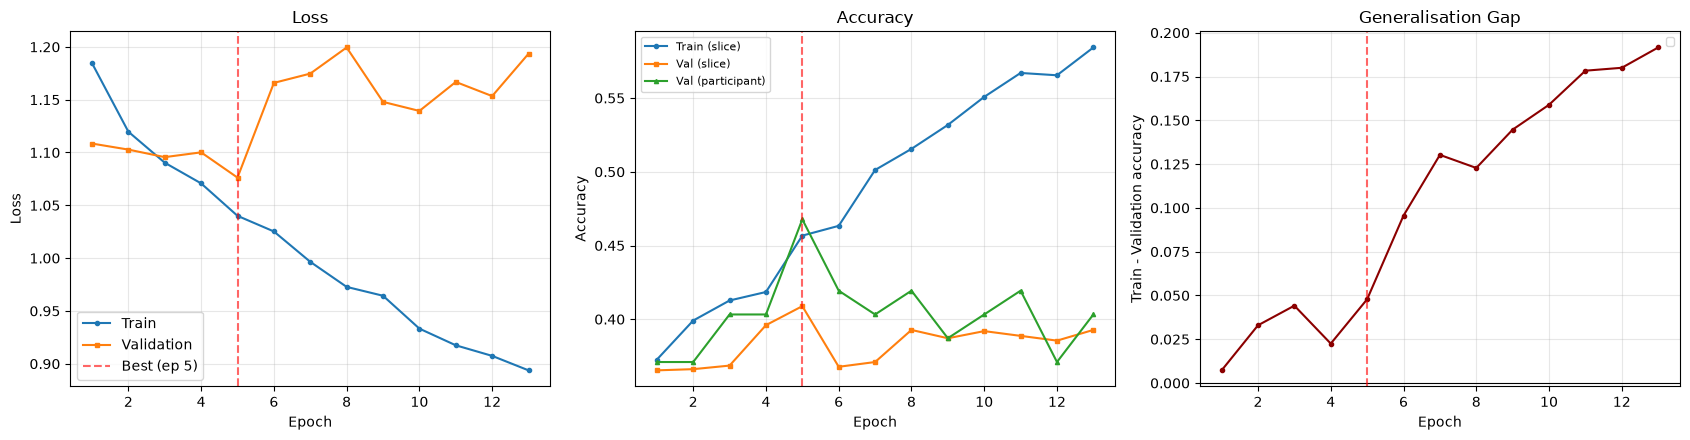

In [37]:
# ============================================================
# Training Curves
#
# Training and validation performance are plotted across epochs
# to examine convergence and the difference between training and
# validation accuracy.
# ============================================================

epochs_run = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# ---- loss ----
axes[0].plot(epochs_run, history["train_loss"], label="Train", marker="o", ms=3)
axes[0].plot(epochs_run, history["validation_loss"], label="Validation", marker="s", ms=3)
axes[0].axvline(best_epoch, color="red", ls="--", alpha=0.6, label=f"Best (ep {best_epoch})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---- accuracy ----
axes[1].plot(epochs_run, history["train_slice_accuracy"], label="Train (slice)", marker="o", ms=3)
axes[1].plot(epochs_run, history["validation_slice_accuracy"], label="Val (slice)", marker="s", ms=3)
axes[1].plot(epochs_run, history["validation_participant_accuracy"], label="Val (participant)", marker="^", ms=3)
axes[1].axvline(best_epoch, color="red", ls="--", alpha=0.6)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# ---- generalisation gap ----
gap_series = [
    t - v for t, v in zip(
        history["train_slice_accuracy"],
        history["validation_slice_accuracy"],
    )
]

axes[2].plot(epochs_run, gap_series, color="darkred", marker="o", ms=3)
axes[2].axhline(0, color="black", lw=0.8)
axes[2].axvline(best_epoch, color="red", ls="--", alpha=0.6)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Train - Validation accuracy")
axes[2].set_title("Generalisation Gap")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4.1 Deep Learning Evaluation

Both slice-level and participant-level performance are evaluated. Participant-level results are used as the primary deep-learning evaluation because multiple MRI slices from the same participant are highly correlated and should not be treated as independent observations.

Participant-level predictions are obtained by averaging the predicted class probabilities across all slices belonging to each participant and selecting the class with the highest mean probability.

The majority-class baseline is reported alongside the model results to provide a reference point for interpreting classification performance in the presence of class imbalance.


In [ ]:
# ============================================================
# Evaluate on the Test Set
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

test_metrics = evaluate_epoch(
    resnet_model,
    test_loader,
    test_dataset,
    criterion,
    device,
)

# ------------------------------------------------------------
# Majority-class baselines
# ------------------------------------------------------------

slice_majority = (
    pd.Series(test_metrics["slice_labels"])
    .value_counts(normalize=True)
    .max()
)

participant_majority = (
    pd.Series(test_metrics["participant_labels"])
    .value_counts(normalize=True)
    .max()
)

# ------------------------------------------------------------
# Slice-level evaluation
# ------------------------------------------------------------

print("=" * 62)
print("ResNet-18  |  SLICE LEVEL")
print("=" * 62)

print(f"Accuracy          : {test_metrics['slice_accuracy']:.4f}")
print(f"Majority baseline : {slice_majority:.4f}")
print(
    f"Improvement       : "
    f"{test_metrics['slice_accuracy'] - slice_majority:+.4f}"
)

print(
    "\n" + classification_report(
        test_metrics["slice_labels"],
        test_metrics["slice_predictions"],
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

# ------------------------------------------------------------
# Participant-level evaluation (primary result)
# ------------------------------------------------------------

participant_labels = test_metrics["participant_labels"]
participant_predictions = test_metrics["participant_predictions"]

cnn_accuracy = accuracy_score(
    participant_labels,
    participant_predictions,
)

cnn_balanced = balanced_accuracy_score(
    participant_labels,
    participant_predictions,
)

cnn_precision = precision_score(
    participant_labels,
    participant_predictions,
    labels=[0, 1, 2],
    average="macro",
    zero_division=0,
)

cnn_recall = recall_score(
    participant_labels,
    participant_predictions,
    labels=[0, 1, 2],
    average="macro",
    zero_division=0,
)

cnn_f1 = f1_score(
    participant_labels,
    participant_predictions,
    labels=[0, 1, 2],
    average="macro",
    zero_division=0,
)

cnn_mcc = matthews_corrcoef(
    participant_labels,
    participant_predictions,
)

print("=" * 62)
print("ResNet-18  |  PARTICIPANT LEVEL  (primary)")
print("=" * 62)

print(f"Participants      : {len(participant_labels)}")
print(f"Accuracy          : {cnn_accuracy:.4f}")
print(f"Balanced accuracy : {cnn_balanced:.4f}")
print(f"Precision (macro) : {cnn_precision:.4f}")
print(f"Recall (macro)    : {cnn_recall:.4f}")
print(f"F1 (macro)        : {cnn_f1:.4f}")
print(f"Majority baseline : {participant_majority:.4f}")
print(
    f"Improvement       : "
    f"{cnn_accuracy - participant_majority:+.4f}"
)
print(f"MCC               : {cnn_mcc:.4f}")

print(
    "\n" + classification_report(
        participant_labels,
        participant_predictions,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

ResNet-18  |  SLICE LEVEL
Accuracy          : 0.4194
Majority baseline : 0.4839
Improvement       : -0.0645

              precision    recall  f1-score   support

          CN       0.42      0.53      0.47       360
         MCI       0.49      0.34      0.40       600
          AD       0.34      0.44      0.38       280

    accuracy                           0.42      1240
   macro avg       0.42      0.44      0.42      1240
weighted avg       0.43      0.42      0.42      1240

ResNet-18  |  PARTICIPANT LEVEL  (primary)
Participants      : 62
Accuracy          : 0.4677
Balanced accuracy : 0.4873
Precision (macro) : 0.4600
Recall (macro)    : 0.4873
F1 (macro)        : 0.4689
Majority baseline : 0.4839
Improvement       : -0.0161
MCC               : 0.1839

              precision    recall  f1-score   support

          CN       0.52      0.67      0.59        18
         MCI       0.46      0.37      0.41        30
          AD       0.40      0.43      0.41        14

    accu

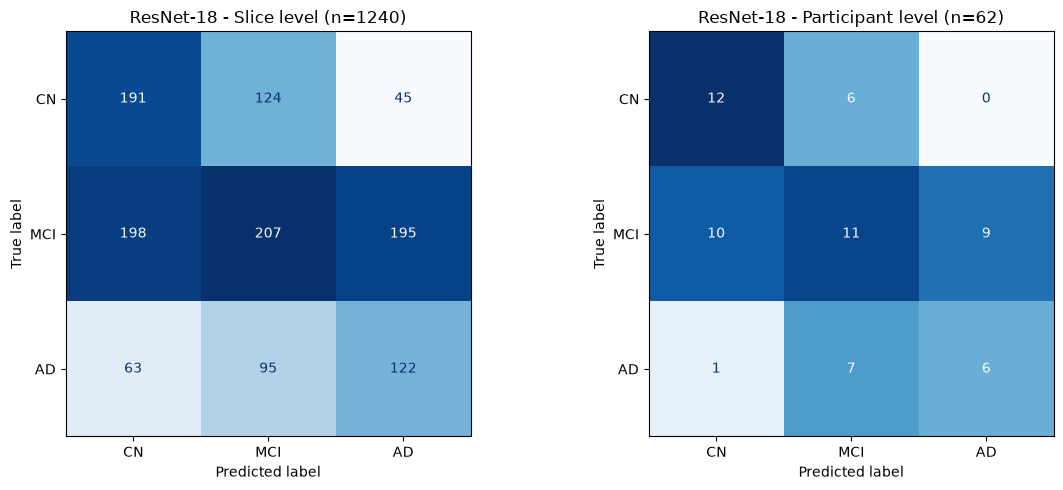

In [39]:
# ============================================================
# Test-Set Confusion Matrices
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (labels_true, labels_pred, title) in zip(axes, [
    (test_metrics["slice_labels"], test_metrics["slice_predictions"],
     f"Slice level (n={len(test_metrics['slice_labels'])})"),
    (participant_labels, participant_predictions,
     f"Participant level (n={len(participant_labels)})"),
]):
    cm = confusion_matrix(labels_true, labels_pred, labels=[0, 1, 2])
    ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=CLASS_NAMES
    ).plot(cmap="Blues", ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"ResNet-18 - {title}")

plt.tight_layout()
plt.show()

## 5.5 Hybrid AI Branch

The hybrid AI branch combines deep representations extracted from the ResNet-18 with MRI-derived structural biomarkers. The aim is to determine whether complementary information from image-based deep features and established structural measurements can improve multiclass classification of CN, MCI, and AD.

For each participant, deep features are extracted from the trained ResNet-18 and averaged across the participant's MRI slices to obtain a single deep feature representation. These features are then combined with the structural biomarker features used in the traditional machine learning branch.

An XGBoost classifier is used to model the combined feature space. Feature preprocessing is performed within the modelling pipeline to reduce the risk of information leakage during model evaluation.

### Evaluation Strategy

Hybrid performance is evaluated at participant level. Particular attention is given to maintaining separation between data used to train the CNN feature extractor and data used to evaluate the final hybrid classifier.

A held-out evaluation is used as the primary hybrid result, where participants in the test set are not used to train the ResNet-18 or the hybrid classifier. This provides the cleanest estimate of performance on unseen participants.

Repeated stratified cross-validation is also used as a supplementary robustness analysis where appropriate. Results involving deep features extracted by a CNN that has previously been trained on participants included in the cross-validation cohort are interpreted cautiously, because the feature extractor may already contain information learned from those participants.

The hybrid results are therefore reported together with their evaluation protocol rather than treating results obtained under different validation procedures as directly equivalent.


In [40]:
# ============================================================
# Extract Participant-Level Deep Features
#
# The trained ResNet-18 is used as a feature extractor by
# removing its final classification head. Each MRI slice is
# represented by a 512-dimensional deep feature vector, and
# slice-level features are averaged to obtain one representation
# per participant.
# ============================================================


feature_extractor = nn.Sequential(
    *list(resnet_model.children())[:-1]
).to(device).eval()


def extract_deep_features(dataset, batch_size=32):
    """Slice-level 512-d features, averaged per participant."""

    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=torch.cuda.is_available(),
    )

    features = []
    indices = []

    with torch.no_grad():
        for images, _, index in loader:
            images = images.to(device, non_blocking=True)
            output = feature_extractor(images).flatten(start_dim=1)
            features.append(output.cpu().numpy())
            indices.append(index.numpy())

    features = np.concatenate(features)
    indices = np.concatenate(indices)

    frame = pd.DataFrame(
        features,
        columns=[f"DL_{i:03d}" for i in range(features.shape[1])],
    )
    frame.insert(0, "Subject", dataset.participant_ids[indices])

    return frame.groupby("Subject", as_index=False).mean()


train_features = extract_deep_features(train_dataset)
validation_features = extract_deep_features(validation_dataset)
test_features = extract_deep_features(test_dataset)

train_features["Split"] = "Train"
validation_features["Split"] = "Validation"
test_features["Split"] = "Test"

all_deep_features = pd.concat(
    [train_features, validation_features, test_features],
    ignore_index=True,
)

print("Participant-level deep features:")
print("  Train      :", train_features.shape)
print("  Validation :", validation_features.shape)
print("  Test       :", test_features.shape)
print("  Combined   :", all_deep_features.shape)

Participant-level deep features:
  Train      : (287, 514)
  Validation : (62, 514)
  Test       : (62, 514)
  Combined   : (411, 514)


In [ ]:
# ============================================================
# Assemble the Hybrid Dataset
# ============================================================

hybrid_biomarkers = bd[
    ["Subject", "Group"] + FEATURE_COLUMNS
].copy()

hybrid_dataset = all_deep_features.merge(
    hybrid_biomarkers,
    on="Subject",
    how="inner",
)

deep_feature_columns = [
    c for c in hybrid_dataset.columns
    if c.startswith("DL_")
]

print(
    "Participants with deep features :",
    all_deep_features["Subject"].nunique(),
)

print(
    "Participants with biomarkers    :",
    hybrid_biomarkers["Subject"].nunique(),
)

print(
    "Hybrid participants (both)      :",
    hybrid_dataset["Subject"].nunique(),
)

print("\nBy original split:")

print(
    hybrid_dataset["Split"]
    .value_counts()
    .reindex(
        ["Train", "Validation", "Test"],
        fill_value=0,
    )
    .to_string()
)

print("\nBy diagnosis:")

print(
    hybrid_dataset["Group"]
    .value_counts()
    .to_string()
)


# ------------------------------------------------------------
# Check diagnostic class coverage in the held-out test split
# ------------------------------------------------------------

test_groups = hybrid_dataset.loc[
    hybrid_dataset["Split"] == "Test",
    "Group",
]

present_classes = set(test_groups.unique())
missing_classes = set(CLASS_NAMES) - present_classes

print("\nHeld-out hybrid test split:")
print(f"Participants : {len(test_groups)}")
print(
    "Classes      :",
    sorted(present_classes)
)

if missing_classes:
    print(
        "Missing classes:",
        sorted(missing_classes)
    )
else:
    print(
        "All diagnostic classes are represented."
    )

Participants with deep features : 411
Participants with biomarkers    : 260
Hybrid participants (both)      : 260

By original split:
Split
Train         184
Validation     39
Test           37

By diagnosis:
Group
MCI    130
CN      77
AD      53

Held-out hybrid test split:
Participants : 37
Classes      : ['AD', 'CN', 'MCI']
All diagnostic classes are represented.


In [42]:
# ============================================================
# Hybrid Feature Construction
#
# Deep features and structural biomarkers are processed within
# the modelling pipeline so that scaling and PCA are fitted only
# on the training portion of each evaluation split.
#
# This prevents information from validation or test participants
# from influencing the learned feature transformation.
# ============================================================

from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, TransformerMixin


class HybridFeatureBuilder(BaseEstimator, TransformerMixin):
    """
    Scales deep features, reduces them with PCA, scales the
    structural biomarkers, and concatenates the two blocks.

    Implemented as a transformer so the whole operation is
    refitted per fold inside a Pipeline.
    """

    def __init__(self, n_deep, pca_variance=0.95,
                 random_state=42):
        self.n_deep = n_deep
        self.pca_variance = pca_variance
        self.random_state = random_state

    def fit(self, X, y=None):
        deep = X[:, :self.n_deep]
        biomarker = X[:, self.n_deep:]

        self.deep_scaler_ = StandardScaler().fit(deep)
        self.pca_ = PCA(
            n_components=self.pca_variance,
            random_state=self.random_state,
        ).fit(self.deep_scaler_.transform(deep))

        self.biomarker_scaler_ = StandardScaler().fit(biomarker)
        return self

    def transform(self, X):
        deep = X[:, :self.n_deep]
        biomarker = X[:, self.n_deep:]

        deep_pca = self.pca_.transform(
            self.deep_scaler_.transform(deep)
        )
        biomarker_scaled = self.biomarker_scaler_.transform(biomarker)

        return np.hstack([deep_pca, biomarker_scaled])


# ---- assemble the raw hybrid matrix ----
X_hybrid_raw = np.hstack([
    hybrid_dataset[deep_feature_columns].values,
    hybrid_dataset[FEATURE_COLUMNS].values,
])

y_hybrid = hybrid_dataset["Group"].map(LABEL_MAP).values
hybrid_subjects = hybrid_dataset["Subject"].values
hybrid_splits = hybrid_dataset["Split"].values

N_DEEP = len(deep_feature_columns)

print("Hybrid matrix     :", X_hybrid_raw.shape)
print("Deep block        :", N_DEEP)
print("Biomarker block   :", len(FEATURE_COLUMNS))
print("Class counts      :", dict(zip(
    CLASS_NAMES, np.bincount(y_hybrid, minlength=3))))

Hybrid matrix     : (260, 521)
Deep block        : 512
Biomarker block   : 9
Class counts      : {'CN': np.int64(77), 'MCI': np.int64(130), 'AD': np.int64(53)}


Hybrid AI  |  Repeated Stratified Cross-Validation
Participants      : 260
Accuracy          : 0.5315 +/- 0.0557
Balanced accuracy : 0.4554
Precision (macro) : 0.5102
Recall (macro)    : 0.4554
F1 (macro)        : 0.4587 +/- 0.0698
MCC (OOF)         : 0.1555
Majority baseline : 0.5000

Classification report (single-pass out-of-fold)
              precision    recall  f1-score   support

          CN       0.43      0.32      0.37        77
         MCI       0.54      0.72      0.62       130
          AD       0.45      0.25      0.32        53

    accuracy                           0.51       260
   macro avg       0.47      0.43      0.44       260
weighted avg       0.49      0.51      0.48       260



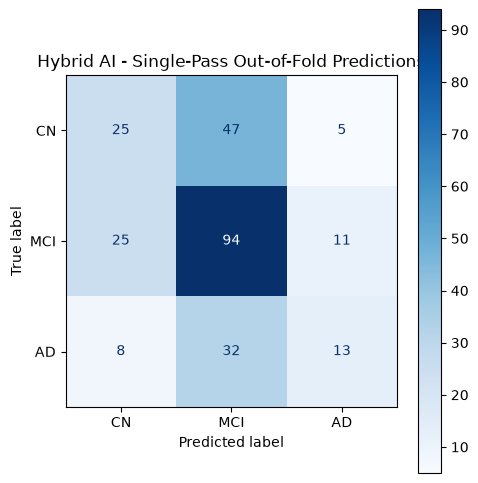

In [44]:
# ============================================================
# Hybrid Model - Repeated Cross-Validation
#
# The hybrid model combines structural biomarker features with
# deep features extracted from the CNN. Performance is assessed
# using repeated stratified cross-validation at participant level.
#
# A separate single stratified cross-validation pass is used to
# obtain one out-of-fold prediction for each participant for the
# classification report, confusion matrix, and MCC.
# ============================================================

hybrid_pipeline = Pipeline([
    ("features", HybridFeatureBuilder(n_deep=N_DEEP)),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=2.0,
        min_child_weight=3,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
    )),
])

# ---- repeated stratified cross-validation ----
hybrid_scores = cross_validate(
    hybrid_pipeline,
    X_hybrid_raw,
    y_hybrid,
    cv=cv_repeated,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "precision": "precision_macro",
        "recall": "recall_macro",
        "f1": "f1_macro",
    },
    n_jobs=-1,
)

# ---- out-of-fold predictions ----
hybrid_oof_predictions = cross_val_predict(
    hybrid_pipeline,
    X_hybrid_raw,
    y_hybrid,
    cv=cv_single,
    n_jobs=-1,
)

ml_predictions["Hybrid AI"] = hybrid_oof_predictions

# ---- repeated CV summary metrics ----
hybrid_accuracy = hybrid_scores["test_accuracy"].mean()
hybrid_balanced = hybrid_scores["test_balanced_accuracy"].mean()
hybrid_precision = hybrid_scores["test_precision"].mean()
hybrid_recall = hybrid_scores["test_recall"].mean()
hybrid_f1 = hybrid_scores["test_f1"].mean()

# MCC is calculated from the single-pass out-of-fold predictions
hybrid_mcc = matthews_corrcoef(
    y_hybrid,
    hybrid_oof_predictions,
)

hybrid_majority = (
    np.bincount(y_hybrid).max() / len(y_hybrid)
)

# ---- results ----
print("=" * 62)
print("Hybrid AI  |  Repeated Stratified Cross-Validation")
print("=" * 62)

print(f"Participants      : {len(y_hybrid)}")
print(
    f"Accuracy          : {hybrid_accuracy:.4f} "
    f"+/- {hybrid_scores['test_accuracy'].std():.4f}"
)
print(f"Balanced accuracy : {hybrid_balanced:.4f}")
print(f"Precision (macro) : {hybrid_precision:.4f}")
print(f"Recall (macro)    : {hybrid_recall:.4f}")
print(
    f"F1 (macro)        : {hybrid_f1:.4f} "
    f"+/- {hybrid_scores['test_f1'].std():.4f}"
)
print(f"MCC (OOF)         : {hybrid_mcc:.4f}")
print(f"Majority baseline : {hybrid_majority:.4f}")

# ---- out-of-fold classification report ----
print()
print("Classification report (single-pass out-of-fold)")
print(
    classification_report(
        y_hybrid,
        hybrid_oof_predictions,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

# ---- out-of-fold confusion matrix ----
fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_hybrid,
        hybrid_oof_predictions,
        labels=[0, 1, 2],
    ),
    display_labels=CLASS_NAMES,
).plot(
    cmap="Blues",
    ax=ax,
    values_format="d",
)

ax.set_title("Hybrid AI - Single-Pass Out-of-Fold Predictions")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Hybrid Model - Leak-Free Held-Out Evaluation (Primary)
#
# The hybrid model is trained using participants from the
# original training and validation splits and evaluated only on
# participants from the held-out test split.
#
# Test participants were not used to train the ResNet-18 feature
# extractor or the hybrid classifier, providing the primary
# leak-free evaluation of the hybrid model.
# ============================================================

train_mask = np.isin(
    hybrid_splits,
    ["Train", "Validation"]
)

test_mask = hybrid_splits == "Test"

X_holdout_train = X_hybrid_raw[train_mask]
y_holdout_train = y_hybrid[train_mask]

X_holdout_test = X_hybrid_raw[test_mask]
y_holdout_test = y_hybrid[test_mask]


print(
    f"Held-out train : {len(y_holdout_train)} participants "
    f"{dict(zip(CLASS_NAMES, np.bincount(y_holdout_train, minlength=3)))}"
)

print(
    f"Held-out test  : {len(y_holdout_test)} participants "
    f"{dict(zip(CLASS_NAMES, np.bincount(y_holdout_test, minlength=3)))}"
)


if len(y_holdout_test) > 0:

    holdout_pipeline = Pipeline([
        (
            "features",
            HybridFeatureBuilder(
                n_deep=N_DEEP,
                random_state=RANDOM_SEED,
            ),
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=2,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=2.0,
                min_child_weight=3,
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=RANDOM_SEED,
            ),
        ),
    ])

    holdout_pipeline.fit(
        X_holdout_train,
        y_holdout_train,
    )

    holdout_predictions = holdout_pipeline.predict(
        X_holdout_test
    )

    # All three diagnostic classes are included explicitly when
    # calculating macro-averaged metrics.
    holdout_accuracy = accuracy_score(
        y_holdout_test,
        holdout_predictions,
    )

    holdout_balanced = balanced_accuracy_score(
        y_holdout_test,
        holdout_predictions,
    )

    holdout_precision = precision_score(
        y_holdout_test,
        holdout_predictions,
        labels=[0, 1, 2],
        average="macro",
        zero_division=0,
    )

    holdout_recall = recall_score(
        y_holdout_test,
        holdout_predictions,
        labels=[0, 1, 2],
        average="macro",
        zero_division=0,
    )

    holdout_f1 = f1_score(
        y_holdout_test,
        holdout_predictions,
        labels=[0, 1, 2],
        average="macro",
        zero_division=0,
    )

    holdout_mcc = matthews_corrcoef(
        y_holdout_test,
        holdout_predictions,
    )

    holdout_majority = (
        np.bincount(y_holdout_test).max()
        / len(y_holdout_test)
    )

    print("\n" + "=" * 62)
    print("Hybrid AI  |  PRIMARY HELD-OUT EVALUATION")
    print("=" * 62)

    print(f"Participants       : {len(y_holdout_test)}")
    print(f"Accuracy           : {holdout_accuracy:.4f}")
    print(f"Balanced accuracy  : {holdout_balanced:.4f}")
    print(f"Precision (macro)  : {holdout_precision:.4f}")
    print(f"Recall (macro)     : {holdout_recall:.4f}")
    print(f"F1 (macro)         : {holdout_f1:.4f}")
    print(f"MCC                : {holdout_mcc:.4f}")
    print(f"Majority baseline  : {holdout_majority:.4f}")

    print(
        "\n" + classification_report(
            y_holdout_test,
            holdout_predictions,
            labels=[0, 1, 2],
            target_names=CLASS_NAMES,
            zero_division=0,
        )
    )

    absent = [
        CLASS_NAMES[i]
        for i in range(3)
        if np.sum(y_holdout_test == i) == 0
    ]

    if absent:
        print(
            f"Classes absent from this test split: "
            f"{absent}"
        )

else:
    print("\nNo held-out test participants available.")

Held-out train : 223 participants {'CN': np.int64(66), 'MCI': np.int64(110), 'AD': np.int64(47)}
Held-out test  : 37 participants {'CN': np.int64(11), 'MCI': np.int64(20), 'AD': np.int64(6)}

Hybrid AI  |  PRIMARY HELD-OUT EVALUATION
Participants       : 37
Accuracy           : 0.4865
Balanced accuracy  : 0.3545
Precision (macro)  : 0.3157
Recall (macro)     : 0.3545
F1 (macro)         : 0.3333
MCC                : 0.0720
Majority baseline  : 0.5405

              precision    recall  f1-score   support

          CN       0.36      0.36      0.36        11
         MCI       0.58      0.70      0.64        20
          AD       0.00      0.00      0.00         6

    accuracy                           0.49        37
   macro avg       0.32      0.35      0.33        37
weighted avg       0.42      0.49      0.45        37



## 5.6 Model Performance Summary

The performance of the traditional machine learning, deep learning, and hybrid AI branches is summarised below. Because the models are evaluated using different validation protocols, the results are presented together for descriptive comparison rather than as a direct statistical ranking.

Traditional machine learning models are evaluated using repeated stratified cross-validation on the structural biomarker cohort. ResNet-18 is evaluated at participant level on the held-out MRI test set. The primary Hybrid AI result is also obtained from a leak-free held-out evaluation, using participants who were not used to train either the ResNet-18 feature extractor or the hybrid classifier.

The evaluation protocol and number of participants are therefore reported alongside each model's performance metrics. Differences between models should be interpreted in the context of these protocols rather than attributed solely to model architecture.

Majority-class baselines are also reported where appropriate to provide context for performance under class imbalance.


In [ ]:
# ============================================================
# Assemble the Model Performance Summary
# ============================================================

comparison_rows = [
    {**logistic_results},
    {**svm_results},
    {**rf_results},
    {**xgb_results},

    {
        "Model": "ResNet-18",
        "Accuracy": cnn_accuracy,
        "Accuracy SD": np.nan,
        "Balanced Accuracy": cnn_balanced,
        "Precision": cnn_precision,
        "Recall": cnn_recall,
        "F1": cnn_f1,
        "F1 SD": np.nan,
        "MCC": cnn_mcc,
        "Protocol": (
            f"Held-out test, "
            f"n={len(participant_labels)} participants"
        ),
    },

    {
        "Model": "Hybrid AI",
        "Accuracy": holdout_accuracy,
        "Accuracy SD": np.nan,
        "Balanced Accuracy": holdout_balanced,
        "Precision": holdout_precision,
        "Recall": holdout_recall,
        "F1": holdout_f1,
        "F1 SD": np.nan,
        "MCC": holdout_mcc,
        "Protocol": (
            f"Leak-free held-out test, "
            f"n={len(y_holdout_test)} participants"
        ),
    },

    {
        "Model": "Majority-class baseline",
        "Accuracy": majority_baseline_ml,
        "Accuracy SD": np.nan,
        "Balanced Accuracy": 1.0 / 3.0,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
        "F1 SD": np.nan,
        "MCC": 0.0,
        "Protocol": "Always predicts the majority class",
    },
]

final_results = pd.DataFrame(comparison_rows)

# Sort for readability only; models are evaluated under
# different protocols and are not treated as a formal ranking.
final_results = final_results.sort_values(
    "MCC",
    ascending=False,
    kind="mergesort",
).reset_index(drop=True)

numeric_columns = final_results.select_dtypes(
    include="number"
).columns

final_results[numeric_columns] = (
    final_results[numeric_columns].round(4)
)

display(
    final_results[[
        "Model",
        "Accuracy",
        "Accuracy SD",
        "Balanced Accuracy",
        "F1",
        "MCC",
        "Protocol",
    ]]
)

final_results.to_csv(
    RESULTS_FOLDER / "model_comparison.csv",
    index=False,
)

print(
    "\nSaved to",
    RESULTS_FOLDER / "model_comparison.csv"
)

,Model,Accuracy,Accuracy SD,Balanced Accuracy,F1,MCC,Protocol
0,Logistic Regression,0.5346,0.0639,0.5715,0.5361,0.2864,"5x5 CV, n=260 participants"
1,Support Vector Machine,0.4785,0.0539,0.5186,0.4803,0.2300,"5x5 CV, n=260 participants"
2,XGBoost,0.5185,0.0567,0.4408,0.4375,0.1970,"5x5 CV, n=260 participants"
3,ResNet-18,0.4677,NaN,0.4873,0.4689,0.1839,"Held-out test, n=62 participants"
4,Random Forest,0.4446,0.0602,0.4660,0.4392,0.1248,"5x5 CV, n=260 participants"
5,Hybrid AI,0.4865,NaN,0.3545,0.3333,0.0720,"Leak-free held-out test, n=37 participants"
6,Majority-class baseline,0.5000,NaN,0.3333,NaN,0.0000,Always predicts the majority class



Saved to C:\Users\aimen\Documents\GitHub\MSc-Final-Project\results\model_comparison.csv


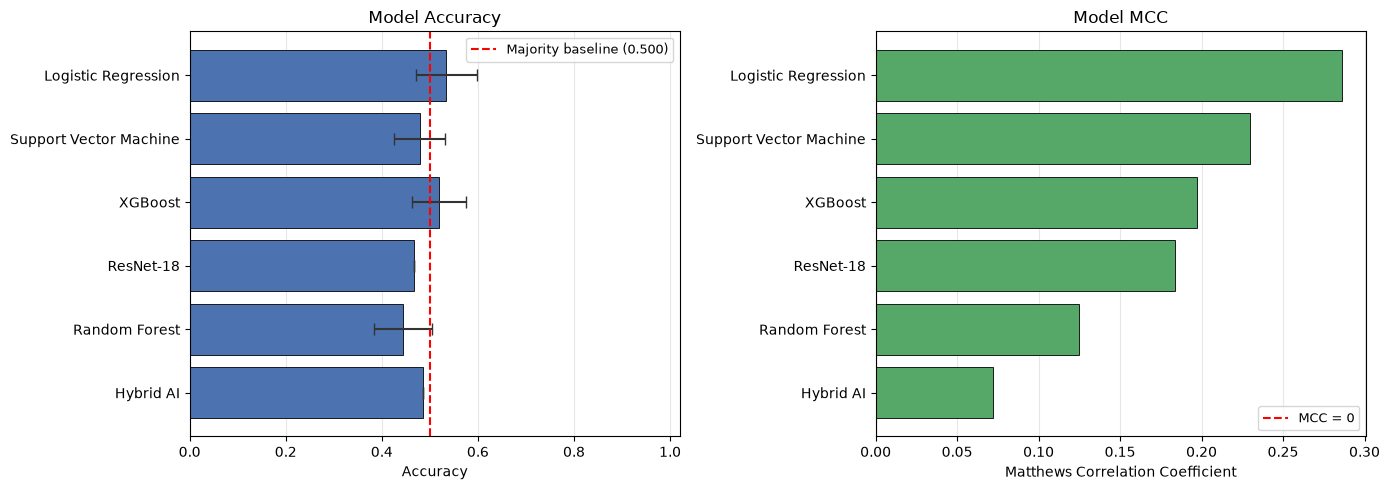

In [ ]:
# ============================================================
# Model Performance Figure
# ============================================================

plot_frame = final_results[
    final_results["Model"] != "Majority-class baseline"
].iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- accuracy ----
positions = np.arange(len(plot_frame))
errors = plot_frame["Accuracy SD"].fillna(0).values

axes[0].barh(
    positions,
    plot_frame["Accuracy"],
    xerr=errors,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.6,
    error_kw={
        "ecolor": "#333",
        "capsize": 4,
    },
)

axes[0].axvline(
    majority_baseline_ml,
    color="red",
    ls="--",
    label=f"Majority baseline ({majority_baseline_ml:.3f})",
)

axes[0].set_yticks(positions)
axes[0].set_yticklabels(plot_frame["Model"])
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Model Accuracy")
axes[0].set_xlim(0, 1.02)
axes[0].legend(fontsize=9)
axes[0].grid(axis="x", alpha=0.3)
axes[0].set_axisbelow(True)

# ---- MCC ----
axes[1].barh(
    positions,
    plot_frame["MCC"],
    color="#55A868",
    edgecolor="black",
    linewidth=0.6,
)

axes[1].axvline(
    0,
    color="red",
    ls="--",
    label="MCC = 0",
)

axes[1].set_yticks(positions)
axes[1].set_yticklabels(plot_frame["Model"])
axes[1].set_xlabel("Matthews Correlation Coefficient")
axes[1].set_title("Model MCC")
axes[1].legend(fontsize=9)
axes[1].grid(axis="x", alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Statistical Comparison - McNemar's Test
#
# McNemar's test is used for paired comparison of classifiers
# evaluated on the same participants. To keep the comparison
# valid, this analysis uses only predictions from a common
# evaluation cohort.
#
# Holm-Bonferroni correction is applied when multiple pairwise
# comparisons are performed.
# ============================================================

from scipy import stats

ALPHA = 0.05


def mcnemar_test(y_true, pred_a, pred_b):
    """
    Compare two classifiers using McNemar's test.

    Returns:
        statistic, p_value, b, c
    """

    a_correct = pred_a == y_true
    b_correct = pred_b == y_true

    # Model A correct, Model B incorrect
    b = int(np.sum(a_correct & ~b_correct))

    # Model A incorrect, Model B correct
    c = int(np.sum(~a_correct & b_correct))

    if b + c == 0:
        return 0.0, 1.0, b, c

    # Use the exact binomial test when the number of discordant
    # predictions is small.
    if b + c < 25:
        p_value = stats.binomtest(
            b,
            b + c,
            p=0.5,
        ).pvalue

        return float(abs(b - c)), float(p_value), b, c

    # Continuity-corrected McNemar statistic
    statistic = (
        (abs(b - c) - 1) ** 2
        / (b + c)
    )

    p_value = stats.chi2.sf(
        statistic,
        df=1,
    )

    return (
        float(statistic),
        float(p_value),
        b,
        c,
    )


def holm_correction(p_values):
    """Apply Holm-Bonferroni correction to multiple p-values."""

    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    n = len(p_values)
    order = np.argsort(p_values)

    adjusted = np.empty(n)
    running_max = 0.0

    for rank, idx in enumerate(order):

        value = (
            n - rank
        ) * p_values[idx]

        running_max = max(
            running_max,
            value,
        )

        adjusted[idx] = min(
            1.0,
            running_max,
        )

    return adjusted


print("McNemar test functions defined.")
print(
    "Pairwise testing will be performed after the common "
    "held-out prediction set is prepared."
)

McNemar test functions defined.
Pairwise testing will be performed after the common held-out prediction set is prepared.


In [ ]:
# ============================================================
# Multi-Seed Robustness Analysis
#
# The CNN and Hybrid models are trained using several random
# seeds to examine how sensitive their participant-level
# performance is to random initialisation and training order.
#
# A fixed number of epochs is used for every seed so that the
# training schedule remains identical across runs. The same
# held-out test participants are used for every seed.
# ============================================================

import time

SEEDS = [42, 7, 123, 2024, 99]
FIXED_EPOCHS = 10


# ------------------------------------------------------------
# Clean datasets for deep-feature extraction
#
# Augmentation is useful during CNN training, but deterministic
# images are used when extracting features for the Hybrid model.
# ------------------------------------------------------------

train_feature_dataset = MRIDataset(
    X_train,
    y_train,
    train_ids,
    transform=evaluation_transform,
    add_noise=False,
)

validation_feature_dataset = MRIDataset(
    X_validation,
    y_validation,
    validation_ids,
    transform=evaluation_transform,
    add_noise=False,
)

test_feature_dataset = MRIDataset(
    X_test,
    y_test,
    test_ids,
    transform=evaluation_transform,
    add_noise=False,
)


def extract_features_with(model, dataset, batch_size=32):
    """Extract participant-level deep features from a trained model."""

    extractor = nn.Sequential(
        *list(model.children())[:-1]
    ).to(device).eval()

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    features = []
    indices = []

    with torch.no_grad():

        for images, _, index in loader:

            images = images.to(
                device,
                non_blocking=True,
            )

            output = extractor(
                images
            ).flatten(start_dim=1)

            features.append(
                output.cpu().numpy()
            )

            indices.append(
                index.numpy()
            )

    features = np.concatenate(features)
    indices = np.concatenate(indices)

    frame = pd.DataFrame(
        features,
        columns=[
            f"DL_{i:03d}"
            for i in range(features.shape[1])
        ],
    )

    frame.insert(
        0,
        "Subject",
        dataset.participant_ids[indices],
    )

    return (
        frame
        .groupby("Subject", as_index=False)
        .mean()
    )


def run_one_seed(seed):
    """
    Train ResNet-18 and the Hybrid model using one random seed
    and evaluate both on the fixed held-out test participants.
    """

    set_seed(seed)
    loader_generator.manual_seed(seed)

    # --------------------------------------------------------
    # Build a new ResNet-18 for this seed
    # --------------------------------------------------------

    model, frozen = build_resnet()
    model = model.to(device)

    backbone = [
        p
        for name, p in model.named_parameters()
        if p.requires_grad
        and not name.startswith("fc")
    ]

    head = [
        p
        for name, p in model.named_parameters()
        if p.requires_grad
        and name.startswith("fc")
    ]

    optimiser = torch.optim.AdamW(
        [
            {
                "params": backbone,
                "lr": 1e-5,
            },
            {
                "params": head,
                "lr": 1e-3,
            },
        ],
        weight_decay=1e-4,
    )

    # --------------------------------------------------------
    # Train for the same number of epochs for every seed
    # --------------------------------------------------------

    for _ in range(FIXED_EPOCHS):

        model.train()

        for name, module in model.named_children():
            if name in frozen:
                module.eval()

        for images, labels, _ in train_loader:

            images = images.to(
                device,
                non_blocking=True,
            )

            labels = labels.to(
                device,
                non_blocking=True,
            )

            optimiser.zero_grad(
                set_to_none=True
            )

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimiser.step()

    # --------------------------------------------------------
    # ResNet-18: participant-level held-out evaluation
    # --------------------------------------------------------

    cnn_metrics = evaluate_epoch(
        model,
        test_loader,
        test_dataset,
        criterion,
        device,
    )

    resnet_mcc = matthews_corrcoef(
        cnn_metrics["participant_labels"],
        cnn_metrics["participant_predictions"],
    )

    resnet_balanced = balanced_accuracy_score(
        cnn_metrics["participant_labels"],
        cnn_metrics["participant_predictions"],
    )

    resnet_accuracy = accuracy_score(
        cnn_metrics["participant_labels"],
        cnn_metrics["participant_predictions"],
    )

    # --------------------------------------------------------
    # Extract deterministic deep features
    # --------------------------------------------------------

    train_seed_features = extract_features_with(
        model,
        train_feature_dataset,
    )
    train_seed_features["Split"] = "Train"

    validation_seed_features = extract_features_with(
        model,
        validation_feature_dataset,
    )
    validation_seed_features["Split"] = "Validation"

    test_seed_features = extract_features_with(
        model,
        test_feature_dataset,
    )
    test_seed_features["Split"] = "Test"

    seed_features = pd.concat(
        [
            train_seed_features,
            validation_seed_features,
            test_seed_features,
        ],
        ignore_index=True,
    )

    # --------------------------------------------------------
    # Assemble Hybrid dataset
    # --------------------------------------------------------

    hybrid = seed_features.merge(
        bd[
            ["Subject", "Group"]
            + FEATURE_COLUMNS
        ],
        on="Subject",
        how="inner",
    )

    deep_columns = [
        c
        for c in hybrid.columns
        if c.startswith("DL_")
    ]

    X = np.hstack([
        hybrid[deep_columns].values,
        hybrid[FEATURE_COLUMNS].values,
    ])

    y = (
        hybrid["Group"]
        .map(LABEL_MAP)
        .values
    )

    splits = hybrid["Split"].values

    train_mask = np.isin(
        splits,
        ["Train", "Validation"],
    )

    test_mask = splits == "Test"

    X_train_hybrid = X[train_mask]
    y_train_hybrid = y[train_mask]

    X_test_hybrid = X[test_mask]
    y_test_hybrid = y[test_mask]

    # --------------------------------------------------------
    # Hybrid: leak-free held-out evaluation
    # --------------------------------------------------------

    hybrid_pipeline = Pipeline([
        (
            "features",
            HybridFeatureBuilder(
                n_deep=len(deep_columns),
                random_state=seed,
            ),
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=2,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=2.0,
                min_child_weight=3,
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=seed,
            ),
        ),
    ])

    hybrid_pipeline.fit(
        X_train_hybrid,
        y_train_hybrid,
    )

    hybrid_predictions = hybrid_pipeline.predict(
        X_test_hybrid
    )

    return {
        "Seed": seed,

        "ResNet Accuracy": resnet_accuracy,
        "ResNet Balanced Acc": resnet_balanced,
        "ResNet MCC": resnet_mcc,

        "Hybrid Accuracy": accuracy_score(
            y_test_hybrid,
            hybrid_predictions,
        ),

        "Hybrid Balanced Acc": balanced_accuracy_score(
            y_test_hybrid,
            hybrid_predictions,
        ),

        "Hybrid MCC": matthews_corrcoef(
            y_test_hybrid,
            hybrid_predictions,
        ),

        "Hybrid Test n": len(y_test_hybrid),
    }


# ============================================================
# Run the Multi-Seed Analysis
# ============================================================

seed_results = []
start = time.time()

for position, seed in enumerate(
    SEEDS,
    start=1,
):

    print(
        f"[{position}/{len(SEEDS)}] "
        f"Seed {seed} ...",
        end=" ",
        flush=True,
    )

    seed_results.append(
        run_one_seed(seed)
    )

    print(
        f"done "
        f"({(time.time() - start) / 60:.1f} min elapsed)"
    )


seed_frame = pd.DataFrame(seed_results)

print()
display(
    seed_frame.round(4)
)


# ============================================================
# Summary Across Seeds
# ============================================================

print("=" * 68)
print(f"ROBUSTNESS ACROSS {len(SEEDS)} RANDOM SEEDS")
print("=" * 68)

metric_columns = [
    "ResNet Accuracy",
    "ResNet Balanced Acc",
    "ResNet MCC",
    "Hybrid Accuracy",
    "Hybrid Balanced Acc",
    "Hybrid MCC",
]

for column in metric_columns:

    values = seed_frame[column]

    print(
        f"{column:<24}: "
        f"{values.mean():.4f} +/- {values.std():.4f} "
        f"[{values.min():.4f}, {values.max():.4f}]"
    )


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

seed_frame.to_csv(
    RESULTS_FOLDER / "multiseed_robustness.csv",
    index=False,
)

print(
    f"\nSaved: "
    f"{RESULTS_FOLDER / 'multiseed_robustness.csv'}"
)

[1/5] Seed 42 ... done (11.6 min elapsed)
[2/5] Seed 7 ... done (25.2 min elapsed)
[3/5] Seed 123 ... done (38.8 min elapsed)
[4/5] Seed 2024 ... done (52.4 min elapsed)
[5/5] Seed 99 ... done (64.7 min elapsed)



,Seed,ResNet Accuracy,ResNet Balanced Acc,ResNet MCC,Hybrid Accuracy,Hybrid Balanced Acc,Hybrid MCC,Hybrid Test n
0,42,0.4839,0.4402,0.1527,0.5405,0.4793,0.2037,37
1,7,0.3548,0.4159,0.1888,0.5135,0.4101,0.1148,37
2,123,0.5161,0.4772,0.2198,0.4324,0.3465,-0.0079,37
3,2024,0.4516,0.4984,0.2229,0.5405,0.4793,0.2012,37
4,99,0.4355,0.4365,0.1577,0.5676,0.4707,0.2435,37


ROBUSTNESS ACROSS 5 RANDOM SEEDS
ResNet Accuracy         : 0.4484 +/- 0.0608 [0.3548, 0.5161]
ResNet Balanced Acc     : 0.4537 +/- 0.0334 [0.4159, 0.4984]
ResNet MCC              : 0.1884 +/- 0.0331 [0.1527, 0.2229]
Hybrid Accuracy         : 0.5189 +/- 0.0520 [0.4324, 0.5676]
Hybrid Balanced Acc     : 0.4372 +/- 0.0584 [0.3465, 0.4793]
Hybrid MCC              : 0.1511 +/- 0.1005 [-0.0079, 0.2435]

Saved: C:\Users\aimen\Documents\GitHub\MSc-Final-Project\results\multiseed_robustness.csv


In [ ]:
# ============================================================
# CNN Exposure Diagnostic
#
# This supplementary analysis checks whether Hybrid performance
# differs between participants used to train the CNN feature
# extractor and participants that were unseen during CNN training.
#
# The analysis is diagnostic only and is not used as the primary
# Hybrid performance estimate.
# ============================================================

DIAGNOSTIC_SEED = RANDOM_SEED
DIAGNOSTIC_EPOCHS = 10

set_seed(DIAGNOSTIC_SEED)
loader_generator.manual_seed(DIAGNOSTIC_SEED)


# ------------------------------------------------------------
# Train a diagnostic ResNet-18
# ------------------------------------------------------------

diag_model, diag_frozen = build_resnet()
diag_model = diag_model.to(device)

backbone = [
    p for name, p in diag_model.named_parameters()
    if p.requires_grad and not name.startswith("fc")
]

head = [
    p for name, p in diag_model.named_parameters()
    if p.requires_grad and name.startswith("fc")
]

diag_optimizer = torch.optim.AdamW(
    [
        {
            "params": backbone,
            "lr": 1e-5,
        },
        {
            "params": head,
            "lr": 1e-3,
        },
    ],
    weight_decay=1e-4,
)


for epoch in range(DIAGNOSTIC_EPOCHS):

    diag_model.train()

    for name, module in diag_model.named_children():
        if name in diag_frozen:
            module.eval()

    for images, labels, _ in train_loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )

        diag_optimizer.zero_grad(
            set_to_none=True
        )

        outputs = diag_model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            diag_model.parameters(),
            max_norm=1.0,
        )

        diag_optimizer.step()

    print(
        f"Epoch {epoch + 1}/{DIAGNOSTIC_EPOCHS} completed"
    )


# ------------------------------------------------------------
# Extract deterministic participant-level deep features
# ------------------------------------------------------------

diag_train_features = extract_features_with(
    diag_model,
    train_feature_dataset,
)

diag_validation_features = extract_features_with(
    diag_model,
    validation_feature_dataset,
)

diag_test_features = extract_features_with(
    diag_model,
    test_feature_dataset,
)

diag_train_features["Split"] = "Train"
diag_validation_features["Split"] = "Validation"
diag_test_features["Split"] = "Test"

diag_features = pd.concat(
    [
        diag_train_features,
        diag_validation_features,
        diag_test_features,
    ],
    ignore_index=True,
)


# ------------------------------------------------------------
# Assemble diagnostic Hybrid dataset
# ------------------------------------------------------------

diag_hybrid = diag_features.merge(
    bd[
        ["Subject", "Group"]
        + FEATURE_COLUMNS
    ],
    on="Subject",
    how="inner",
)

deep_cols = [
    column
    for column in diag_hybrid.columns
    if column.startswith("DL_")
]

X_diag = np.hstack([
    diag_hybrid[deep_cols].values,
    diag_hybrid[FEATURE_COLUMNS].values,
])

y_diag = (
    diag_hybrid["Group"]
    .map(LABEL_MAP)
    .values
)


# ------------------------------------------------------------
# Generate supplementary out-of-fold Hybrid predictions
# ------------------------------------------------------------

diag_pipeline = Pipeline([
    (
        "features",
        HybridFeatureBuilder(
            n_deep=len(deep_cols),
            random_state=DIAGNOSTIC_SEED,
        ),
    ),
    (
        "model",
        XGBClassifier(
            n_estimators=300,
            max_depth=2,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=2.0,
            min_child_weight=3,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=DIAGNOSTIC_SEED,
        ),
    ),
])

diag_oof = cross_val_predict(
    diag_pipeline,
    X_diag,
    y_diag,
    cv=cv_single,
    n_jobs=-1,
)


# ------------------------------------------------------------
# Compare participants by CNN exposure
# ------------------------------------------------------------

diagnostic_results = pd.DataFrame({
    "Split": diag_hybrid["Split"].values,
    "Correct": y_diag == diag_oof,
})

diagnostic_results["CNN_exposed"] = (
    diagnostic_results["Split"] == "Train"
)

print()
print("Hybrid accuracy by CNN exposure")
print("-" * 58)

for exposed, label in [
    (True, "Used during CNN training"),
    (False, "Unseen during CNN training"),
]:

    subset = diagnostic_results[
        diagnostic_results["CNN_exposed"] == exposed
    ]

    print(
        f"{label:<28}: "
        f"{subset['Correct'].mean():.4f} "
        f"(n={len(subset)})"
    )


train_exposed_accuracy = diagnostic_results.loc[
    diagnostic_results["CNN_exposed"],
    "Correct",
].mean()

cnn_unseen_accuracy = diagnostic_results.loc[
    ~diagnostic_results["CNN_exposed"],
    "Correct",
].mean()

exposure_gap = (
    train_exposed_accuracy
    - cnn_unseen_accuracy
)

print(
    f"\nAccuracy difference "
    f"(CNN-exposed - CNN-unseen): "
    f"{exposure_gap:+.4f}"
)

print()
print(
    "This diagnostic is used only to examine the possible effect "
    "of CNN exposure. The primary Hybrid result remains the "
    "leak-free held-out evaluation."
)

Epoch 1/10 completed
Epoch 2/10 completed
Epoch 3/10 completed
Epoch 4/10 completed
Epoch 5/10 completed
Epoch 6/10 completed
Epoch 7/10 completed
Epoch 8/10 completed
Epoch 9/10 completed
Epoch 10/10 completed

Hybrid accuracy by CNN exposure
----------------------------------------------------------
Used during CNN training    : 0.7391 (n=184)
Unseen during CNN training  : 0.5658 (n=76)

Accuracy difference (CNN-exposed - CNN-unseen): +0.1733

This diagnostic is used only to examine the possible effect of CNN exposure. The primary Hybrid result remains the leak-free held-out evaluation.


In [65]:
# ============================================================
# Like-for-Like Comparison on CNN-Unseen Participants
#
# Hybrid and traditional ML predictions are compared on the same
# participants that were not used to train the diagnostic CNN.
# Predictions are aligned explicitly by participant identifier so
# that all models are evaluated on an identical cohort.
# ============================================================

# Validation and test participants were not used to train the
# fixed-epoch diagnostic CNN.
unseen_subjects = diag_hybrid.loc[
    diag_hybrid["Split"] != "Train",
    "Subject",
].values


# ------------------------------------------------------------
# Hybrid predictions
# ------------------------------------------------------------

hybrid_common = pd.DataFrame({
    "Subject": diag_hybrid["Subject"].values,
    "y_true": y_diag,
    "Hybrid AI": diag_oof,
})

hybrid_common = hybrid_common[
    hybrid_common["Subject"].isin(unseen_subjects)
].copy()


# ------------------------------------------------------------
# Traditional ML predictions
# ------------------------------------------------------------

ml_common = pd.DataFrame({
    "Subject": subjects_ml,
    "Logistic Regression": ml_predictions["Logistic Regression"],
    "Support Vector Machine": ml_predictions["Support Vector Machine"],
    "Random Forest": ml_predictions["Random Forest"],
    "XGBoost": ml_predictions["XGBoost"],
})


# ------------------------------------------------------------
# Align all models on exactly the same participants
# ------------------------------------------------------------

common_predictions = hybrid_common.merge(
    ml_common,
    on="Subject",
    how="inner",
)

common_predictions = (
    common_predictions
    .sort_values("Subject")
    .reset_index(drop=True)
)

COMMON_MODEL_NAMES = [
    "Hybrid AI",
    "Logistic Regression",
    "Support Vector Machine",
    "Random Forest",
    "XGBoost",
]

print(
    f"Common CNN-unseen cohort: "
    f"{len(common_predictions)} participants"
)

print("=" * 68)


# ------------------------------------------------------------
# Evaluate each model on the common cohort
# ------------------------------------------------------------

common_rows = []

y_common = common_predictions["y_true"].values

for model_name in COMMON_MODEL_NAMES:

    predictions = common_predictions[
        model_name
    ].values

    accuracy = accuracy_score(
        y_common,
        predictions,
    )

    balanced = balanced_accuracy_score(
        y_common,
        predictions,
    )

    mcc = matthews_corrcoef(
        y_common,
        predictions,
    )

    common_rows.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced,
        "MCC": mcc,
    })

    print(
        f"{model_name:<24}: "
        f"Accuracy {accuracy:.4f}  "
        f"Balanced {balanced:.4f}  "
        f"MCC {mcc:.4f}"
    )


common_comparison = pd.DataFrame(
    common_rows
)

majority_common = (
    pd.Series(y_common)
    .value_counts(normalize=True)
    .max()
)

print(
    f"{'Majority baseline':<24}: "
    f"Accuracy {majority_common:.4f}"
)

print()
print("All models above are evaluated on the same participants. ")
print("Differences should still be interpreted cautiously and are ")
print("examined formally using paired statistical testing.")
    


# ------------------------------------------------------------
# Save common-cohort results
# ------------------------------------------------------------

common_comparison.to_csv(
    RESULTS_FOLDER / "common_cohort_comparison.csv",
    index=False,
)

print(
    f"\nSaved: "
    f"{RESULTS_FOLDER / 'common_cohort_comparison.csv'}"
)

Common CNN-unseen cohort: 76 participants
Hybrid AI               : Accuracy 0.5658  Balanced 0.4792  MCC 0.2468
Logistic Regression     : Accuracy 0.5132  Balanced 0.5212  MCC 0.2585
Support Vector Machine  : Accuracy 0.4211  Balanced 0.4444  MCC 0.1722
Random Forest           : Accuracy 0.3947  Balanced 0.4105  MCC 0.1228
XGBoost                 : Accuracy 0.5132  Balanced 0.4335  MCC 0.1849
Majority baseline       : Accuracy 0.5263

All models above are evaluated on the same participants. 
Differences should still be interpreted cautiously and are 
examined formally using paired statistical testing.

Saved: C:\Users\aimen\Documents\GitHub\MSc-Final-Project\results\common_cohort_comparison.csv


## 5.7 Explainability

Two complementary explainability approaches are used to examine how the models arrive at their predictions:

* **SHAP** is used to quantify the contribution of MRI-derived structural biomarkers to the predictions of the biomarker-based machine learning model.
* **Grad-CAM++** is applied to ResNet-18 to visualise the image regions that contribute most strongly to the CNN's classification decisions.

The Grad-CAM++ analysis is evaluated in relation to the estimated brain region. Attribution outside the brain mask is suppressed for visualisation, and a localisation score is calculated to quantify the proportion of model attribution occurring within brain tissue.

This provides an additional check on whether the CNN is primarily using anatomically relevant image regions rather than background or non-brain structures when making its predictions.


SHAP values shape: (260, 9, 3)


,Feature,Mean |SHAP|
0,Left Hippocampus (/ICV),0.4108
1,Right Hippocampus (/ICV),0.3725
7,White Matter Volume (/ICV),0.2951
8,Intracranial Volume,0.2512
2,Total Hippocampus (/ICV),0.1931
6,Ventricular Volume (/ICV),0.1496
4,Hippocampal Asymmetry (absolute),0.1375
5,Total Entorhinal Cortex (/ICV),0.1304
3,Hippocampal Asymmetry (signed),0.0916


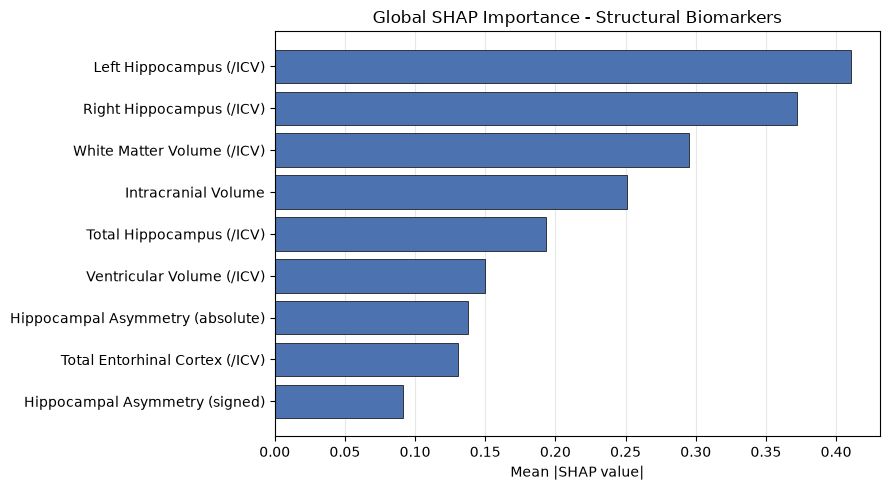

In [66]:
# ============================================================
# SHAP - Structural Biomarker Model
#
# SHAP is used to examine the contribution of each structural
# biomarker to the XGBoost predictions. The model is fitted on
# the full biomarker cohort for interpretation only; predictive
# performance is taken from the cross-validation results above.
# ============================================================

import shap


# ------------------------------------------------------------
# Fit the biomarker model for explanation
# ------------------------------------------------------------

xgb_explainer_model = XGBClassifier(
    **xgb_params
)

xgb_explainer_model.fit(
    X_ml,
    y_ml,
)


# ------------------------------------------------------------
# Calculate SHAP values
# ------------------------------------------------------------

explainer = shap.TreeExplainer(
    xgb_explainer_model
)

shap_values = explainer(
    X_ml
)

print(
    "SHAP values shape:",
    shap_values.values.shape
)


# ------------------------------------------------------------
# Global feature importance
# ------------------------------------------------------------

shap_array = shap_values.values

if shap_array.ndim == 3:
    # Multiclass output:
    # participants x features x classes
    mean_abs_shap = np.abs(
        shap_array
    ).mean(axis=(0, 2))

elif shap_array.ndim == 2:
    # Single-output format
    mean_abs_shap = np.abs(
        shap_array
    ).mean(axis=0)

else:
    raise ValueError(
        f"Unexpected SHAP value shape: "
        f"{shap_array.shape}"
    )


shap_importance = pd.DataFrame({
    "Feature": FEATURE_DISPLAY_NAMES,
    "Mean |SHAP|": mean_abs_shap,
}).sort_values(
    "Mean |SHAP|",
    ascending=False,
)


display(
    shap_importance.round(4)
)


# ------------------------------------------------------------
# Plot global SHAP importance
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.barh(
    shap_importance["Feature"],
    shap_importance["Mean |SHAP|"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()

ax.set_xlabel(
    "Mean |SHAP value|"
)

ax.set_title(
    "Global SHAP Importance - Structural Biomarkers"
)

ax.grid(
    axis="x",
    alpha=0.3
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


SHAP summary - CN


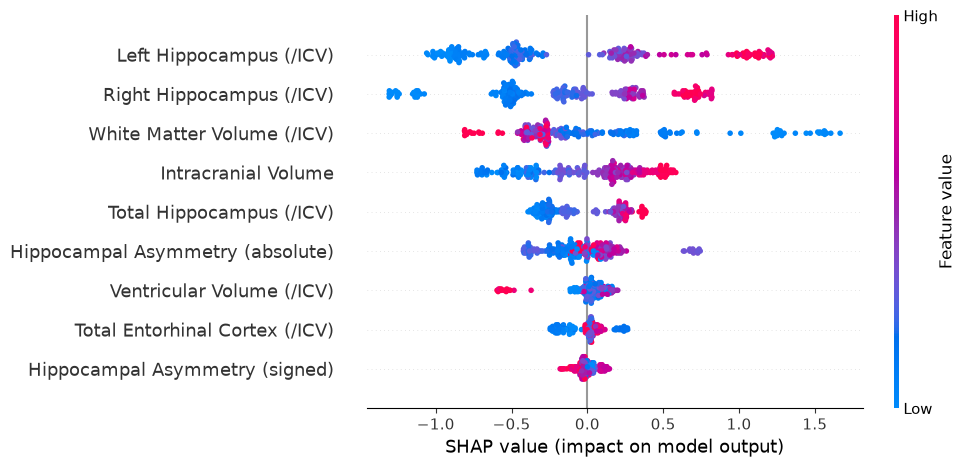


SHAP summary - MCI


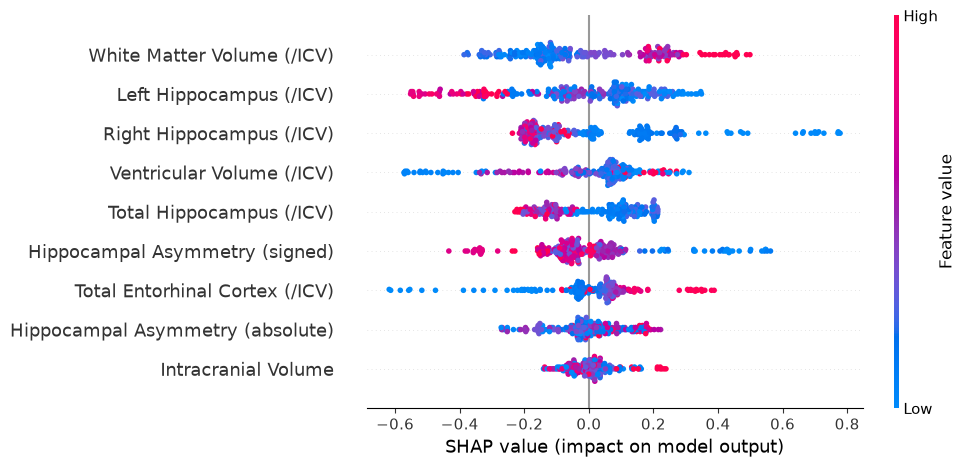


SHAP summary - AD


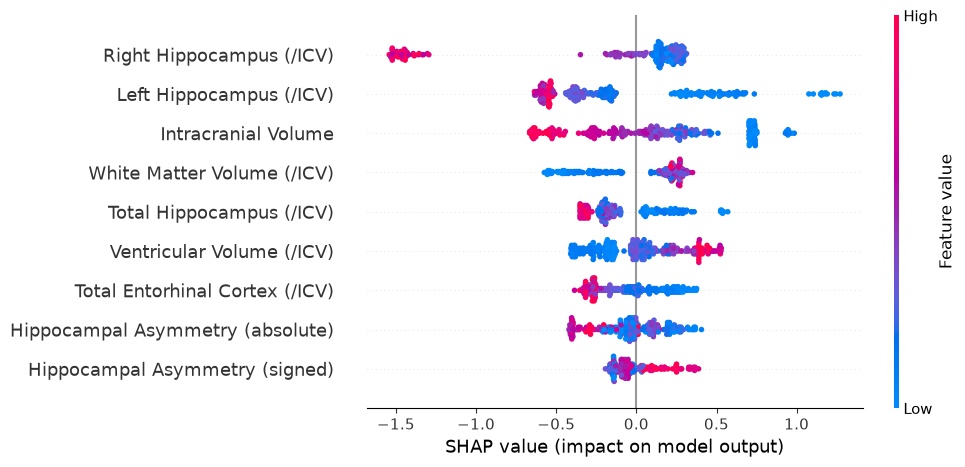

In [67]:
# ============================================================
# SHAP - Per-Class Beeswarm Plots
#
# Separate SHAP beeswarm plots are generated for CN, MCI, and AD
# to show how each structural biomarker contributes to the
# prediction of each diagnostic class.
# ============================================================

X_ml_display = X_ml.copy()
X_ml_display.columns = FEATURE_DISPLAY_NAMES

shap_array = shap_values.values

if shap_array.ndim != 3:
    raise ValueError(
        "Per-class SHAP plots require multiclass SHAP values "
        f"with three dimensions, but received shape "
        f"{shap_array.shape}."
    )


for class_index, class_name in enumerate(CLASS_NAMES):

    print(f"\nSHAP summary - {class_name}")

    class_explanation = shap.Explanation(
        values=shap_array[:, :, class_index],
        base_values=shap_values.base_values[:, class_index],
        data=X_ml_display.values,
        feature_names=FEATURE_DISPLAY_NAMES,
    )

    shap.plots.beeswarm(
        class_explanation,
        max_display=len(FEATURE_DISPLAY_NAMES),
        show=True,
    )

Selected waterfall example
----------------------------------------------
Participant        : 035_S_0341
True diagnosis     : AD
Predicted diagnosis: AD
AD probability     : 0.5695


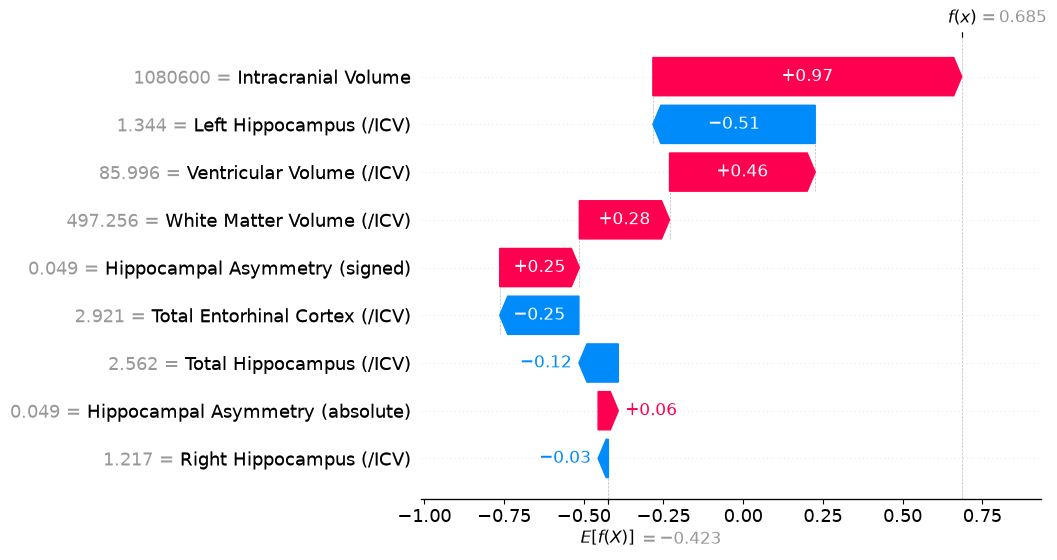

In [68]:
# ============================================================
# SHAP Waterfall - Individual AD Prediction
#
# A single correctly classified AD participant is selected for
# local explanation. To avoid cherry-picking, the participant
# with median prediction confidence among correctly classified
# AD cases is used.
# ============================================================

# ------------------------------------------------------------
# Model predictions and probabilities
# ------------------------------------------------------------

xgb_probabilities = xgb_explainer_model.predict_proba(X_ml)
xgb_predictions = xgb_explainer_model.predict(X_ml)

ad_class = LABEL_MAP["AD"]

correct_ad_indices = np.where(
    (np.asarray(y_ml) == ad_class)
    & (xgb_predictions == ad_class)
)[0]

if len(correct_ad_indices) == 0:
    raise ValueError(
        "No correctly classified AD participants are available "
        "for the SHAP waterfall example."
    )


# ------------------------------------------------------------
# Select the median-confidence correct AD case
# ------------------------------------------------------------

ad_confidences = xgb_probabilities[
    correct_ad_indices,
    ad_class,
]

order = np.argsort(ad_confidences)

selected_position = order[
    len(order) // 2
]

selected_index = correct_ad_indices[
    selected_position
]

selected_subject = subjects_ml[
    selected_index
]

selected_confidence = xgb_probabilities[
    selected_index,
    ad_class,
]


print("Selected waterfall example")
print("-" * 46)
print(f"Participant        : {selected_subject}")
print("True diagnosis     : AD")
print("Predicted diagnosis: AD")
print(f"AD probability     : {selected_confidence:.4f}")


# ------------------------------------------------------------
# Build the AD-class SHAP explanation for this participant
# ------------------------------------------------------------

shap_array = shap_values.values

if shap_array.ndim != 3:
    raise ValueError(
        "The waterfall plot requires multiclass SHAP values "
        f"with three dimensions, but received {shap_array.shape}."
    )

participant_explanation = shap.Explanation(
    values=shap_array[
        selected_index,
        :,
        ad_class,
    ],
    base_values=shap_values.base_values[
        selected_index,
        ad_class,
    ],
    data=X_ml_display.iloc[
        selected_index
    ].values,
    feature_names=FEATURE_DISPLAY_NAMES,
)


# ------------------------------------------------------------
# Waterfall plot
# ------------------------------------------------------------

shap.plots.waterfall(
    participant_explanation,
    max_display=len(FEATURE_DISPLAY_NAMES),
    show=True,
)

In [69]:
# ============================================================
# Univariate Biomarker Analysis - CN vs AD
#
# Each structural biomarker is evaluated individually using
# ROC-AUC to examine its ability to distinguish CN from AD.
#
# This analysis complements SHAP by considering each feature
# independently, without the influence of correlations between
# predictors in a multivariable model.
# ============================================================

univariate = []

for position, name in enumerate(FEATURE_DISPLAY_NAMES):

    values = X_binary.iloc[:, position].values
    auc = roc_auc_score(y_binary, values)

    # AUC below 0.5 indicates that lower feature values are
    # associated with AD rather than higher values.
    univariate.append({
        "Feature": name,
        "AUC": max(auc, 1 - auc),
        "Direction": "lower in AD" if auc < 0.5 else "higher in AD",
    })

univariate = (pd.DataFrame(univariate)
              .sort_values("AUC", ascending=False)
              .reset_index(drop=True))

display(univariate.round(4))

print("AUC = 0.5 indicates no discrimination between CN and AD.")
print("Each biomarker is evaluated independently, so these values ")
print("describe univariate rather than multivariable discrimination.")

,Feature,AUC,Direction
0,Right Hippocampus (/ICV),0.8079,lower in AD
1,Total Hippocampus (/ICV),0.8074,lower in AD
2,Left Hippocampus (/ICV),0.8045,lower in AD
3,Total Entorhinal Cortex (/ICV),0.7366,lower in AD
4,Intracranial Volume,0.6694,higher in AD
5,White Matter Volume (/ICV),0.6462,lower in AD
6,Hippocampal Asymmetry (absolute),0.5920,higher in AD
7,Hippocampal Asymmetry (signed),0.5401,higher in AD
8,Ventricular Volume (/ICV),0.5033,lower in AD


AUC = 0.5 indicates no discrimination between CN and AD.
Each biomarker is evaluated independently, so these values 
describe univariate rather than multivariable discrimination.


In [70]:
# ============================================================
# Grad-CAM++ Utilities
#
# Grad-CAM++ is used to visualise regions contributing to the
# ResNet-18 prediction. Activation maps from layer3 and layer4
# are combined to balance spatial detail and high-level features.
#
# An approximate foreground/brain-region mask is used during
# visualisation to reduce attribution from background areas.
# Localisation is assessed using the original CAM before masking.
# ============================================================

from scipy import ndimage

CAM_BLUR = 1.5
CLIP_PERCENTILE = 99.0
BRAIN_THRESHOLD = 0.08
MAX_ALPHA = 0.65
N_SMOOTH = 8
SMOOTH_SIGMA = 0.10


class GradCAMPlusPlus:

    def __init__(self, model, target_layers):

        self.model = model

        if not isinstance(target_layers, (list, tuple)):
            target_layers = [target_layers]

        self.target_layers = list(target_layers)

        self.activations = {}
        self.gradients = {}
        self.handles = []

        for i, layer in enumerate(self.target_layers):

            self.handles.append(
                layer.register_forward_hook(
                    self._forward_hook(i)
                )
            )

            self.handles.append(
                layer.register_full_backward_hook(
                    self._backward_hook(i)
                )
            )

    def _forward_hook(self, idx):

        def hook(module, inp, out):
            self.activations[idx] = out.detach()

        return hook

    def _backward_hook(self, idx):

        def hook(module, grad_in, grad_out):
            self.gradients[idx] = grad_out[0].detach()

        return hook

    def _cam_from_layer(self, idx):

        activations = self.activations[idx]
        gradients = self.gradients[idx]

        grads2 = gradients ** 2
        grads3 = grads2 * gradients

        sum_activations = activations.sum(
            dim=(2, 3),
            keepdim=True,
        )

        denominator = (
            2.0 * grads2
            + sum_activations * grads3
        )

        denominator = torch.where(
            denominator.abs() > 1e-7,
            denominator,
            torch.ones_like(denominator),
        )

        alpha = grads2 / denominator

        weights = (
            alpha * F.relu(gradients)
        ).sum(
            dim=(2, 3),
            keepdim=True,
        )

        cam = (
            weights * activations
        ).sum(
            dim=1,
            keepdim=True,
        )

        return F.relu(cam)

    def generate(
        self,
        input_tensor,
        class_index=None,
        output_size=None,
        n_smooth=1,
        smooth_sigma=0.0,
    ):

        self.model.zero_grad(
            set_to_none=True
        )

        # Initial prediction used to determine the target class
        # and its confidence.
        with torch.no_grad():

            logits = self.model(
                input_tensor
            )

            probabilities = F.softmax(
                logits,
                dim=1,
            )

        if class_index is None:
            class_index = int(
                logits.argmax(dim=1).item()
            )

        confidence = float(
            probabilities[
                0,
                class_index,
            ].item()
        )

        accumulated = None
        input_std = float(
            input_tensor.std().item()
        )

        # Average CAMs across slightly perturbed inputs to reduce
        # small local variations in the attribution map.
        for pass_index in range(
            max(1, n_smooth)
        ):

            if (
                pass_index == 0
                or smooth_sigma <= 0
            ):
                sample = input_tensor.clone()

            else:
                sample = (
                    input_tensor
                    + torch.randn_like(input_tensor)
                    * smooth_sigma
                    * input_std
                )

            sample = sample.requires_grad_(
                True
            )

            self.model.zero_grad(
                set_to_none=True
            )

            logits = self.model(sample)

            logits[
                0,
                class_index,
            ].backward()

            layer_cams = []
            target_hw = None

            for idx in range(
                len(self.target_layers)
            ):

                if idx not in self.gradients:
                    continue

                cam_layer = (
                    self._cam_from_layer(idx)
                )

                if target_hw is None:
                    target_hw = (
                        cam_layer.shape[-2:]
                    )

                else:
                    target_hw = (
                        max(
                            target_hw[0],
                            cam_layer.shape[-2],
                        ),
                        max(
                            target_hw[1],
                            cam_layer.shape[-1],
                        ),
                    )

                layer_cams.append(
                    cam_layer
                )

            if not layer_cams:
                raise RuntimeError(
                    "No Grad-CAM++ gradients were captured."
                )

            fused = None

            for cam_layer in layer_cams:

                cam_layer = F.interpolate(
                    cam_layer,
                    size=target_hw,
                    mode="bilinear",
                    align_corners=False,
                )

                cam_min = cam_layer.amin(
                    dim=(2, 3),
                    keepdim=True,
                )

                cam_max = cam_layer.amax(
                    dim=(2, 3),
                    keepdim=True,
                )

                cam_layer = (
                    cam_layer - cam_min
                ) / (
                    cam_max
                    - cam_min
                    + 1e-8
                )

                fused = (
                    cam_layer
                    if fused is None
                    else fused + cam_layer
                )

            fused = (
                fused / len(layer_cams)
            )

            accumulated = (
                fused
                if accumulated is None
                else accumulated + fused
            )

        cam = (
            accumulated
            / max(1, n_smooth)
        )

        if output_size is None:
            output_size = (
                input_tensor.shape[-2:]
            )

        cam = F.interpolate(
            cam,
            size=tuple(output_size),
            mode="bilinear",
            align_corners=False,
        )

        return (
            cam.squeeze().cpu().numpy(),
            class_index,
            confidence,
        )

    def remove_hooks(self):

        for handle in self.handles:
            handle.remove()

        self.handles = []


# ============================================================
# Approximate Brain-Region Mask
# ============================================================

def make_brain_mask(
    image,
    threshold=BRAIN_THRESHOLD,
    erode_iterations=2,
):
    """
    Create an approximate brain-region mask from the MRI slice.

    The mask is intended to reduce background attribution during
    visualisation and is not treated as a formal brain segmentation.
    """

    img = np.asarray(
        image,
        dtype=np.float32,
    )

    if img.ndim == 3:
        img = img.mean(axis=-1)

    value_range = (
        img.max() - img.min()
    )

    if value_range > 0:
        img = (
            img - img.min()
        ) / value_range

    binary = ndimage.binary_opening(
        img > threshold,
        structure=np.ones((5, 5)),
        iterations=1,
    )

    labelled, n_components = (
        ndimage.label(binary)
    )

    if n_components == 0:
        return np.ones_like(
            img,
            dtype=np.float32,
        )

    sizes = ndimage.sum(
        binary,
        labelled,
        range(1, n_components + 1),
    )

    largest_component = (
        int(np.argmax(sizes)) + 1
    )

    mask = ndimage.binary_fill_holes(
        labelled == largest_component
    )

    if erode_iterations > 0:

        mask = ndimage.binary_erosion(
            mask,
            structure=np.ones((3, 3)),
            iterations=erode_iterations,
        )

    mask = ndimage.gaussian_filter(
        mask.astype(np.float32),
        sigma=2.0,
    )

    return np.clip(
        mask,
        0.0,
        1.0,
    )


# ============================================================
# CAM Post-Processing
# ============================================================

def postprocess_cam(
    cam,
    brain_mask,
):

    cam = (
        cam * brain_mask
    )

    cam = (
        ndimage.gaussian_filter(
            cam,
            sigma=CAM_BLUR,
        )
        * brain_mask
    )

    inside = cam[
        brain_mask > 0.5
    ]

    if inside.size == 0:
        return np.zeros_like(cam)

    upper = np.percentile(
        inside,
        CLIP_PERCENTILE,
    )

    if upper <= 0:
        return np.zeros_like(cam)

    return np.clip(
        cam / upper,
        0.0,
        1.0,
    )


# ============================================================
# Localisation Score
#
# IMPORTANT:
# Pass the original unmasked CAM to this function. This measures
# how much of the model attribution naturally falls within the
# approximate brain region before visualisation masking.
# ============================================================

def localisation_score(
    raw_cam,
    brain_mask,
):

    total = raw_cam.sum()

    if total <= 0:
        return 0.0

    inside = (
        raw_cam * brain_mask
    ).sum()

    return float(
        inside / total
    )


print("Grad-CAM++ utilities defined.")

Grad-CAM++ utilities defined.


Correctly classified candidate slices: 520


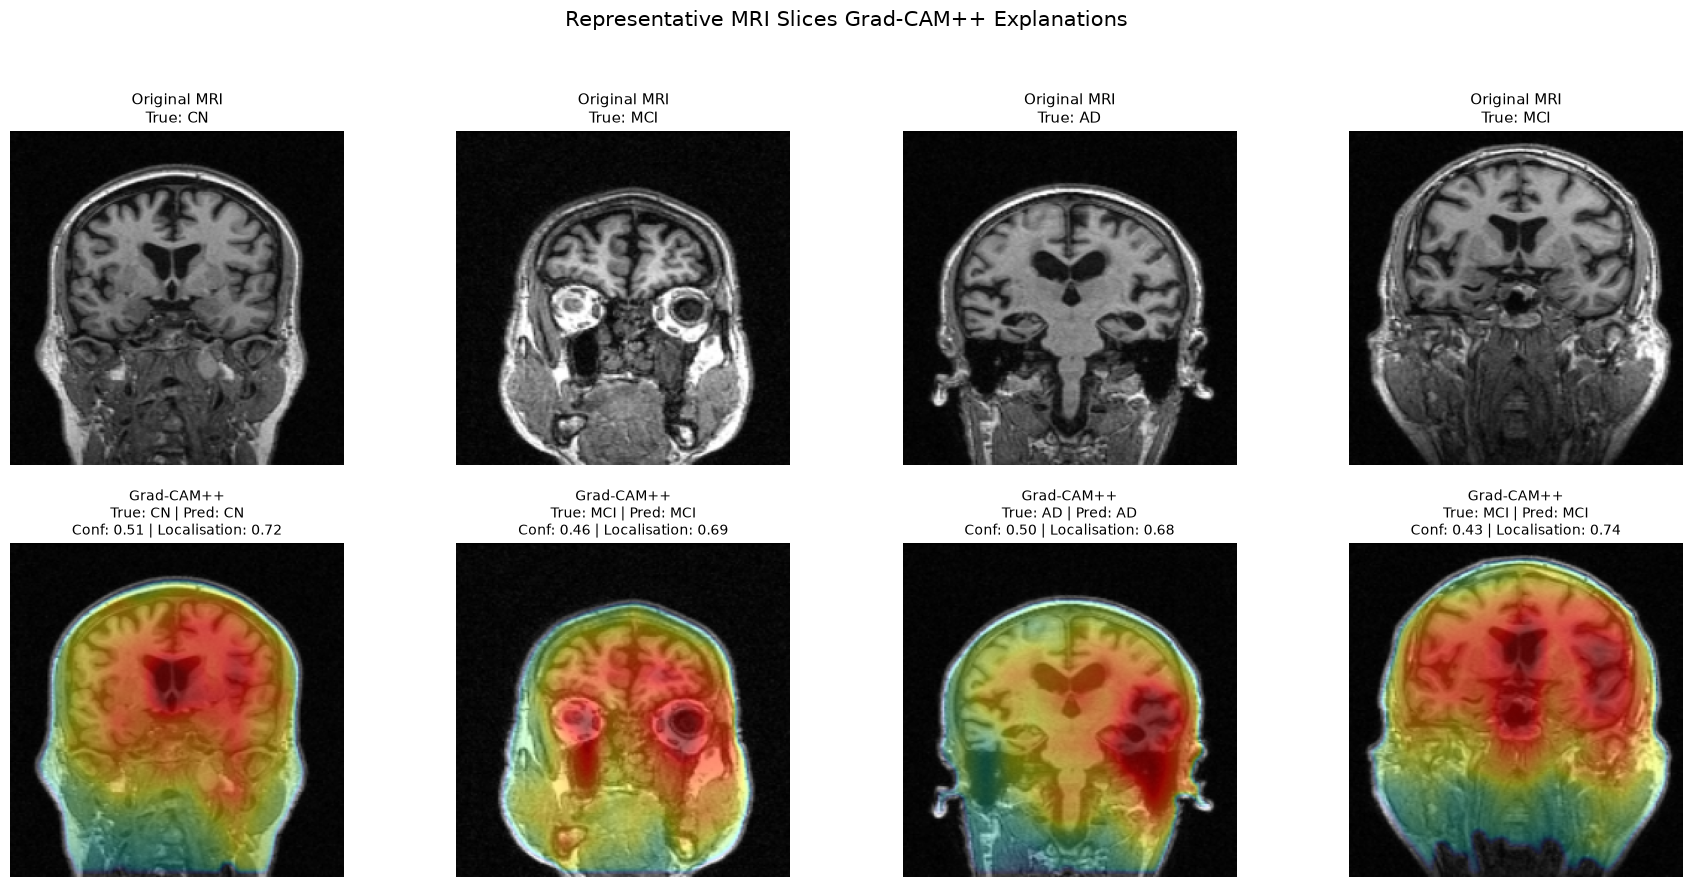


 Index | True | Pred |   Conf | Localis.
--------------------------------------------
   467 |  CN  |  CN  |  0.508 |    0.715
   843 | MCI  | MCI  |  0.462 |    0.693
  1190 |  AD  |  AD  |  0.503 |    0.683
   607 | MCI  | MCI  |  0.435 |    0.741

Mean localisation: 0.708
Localisation is the fraction of pre-mask attribution falling
within the estimated foreground region defined by the mask.
Lower values indicate greater attribution outside this region.


In [71]:
# ============================================================
# Generate Grad-CAM++ Explanations
#
# Representative correctly classified test slices are selected
# using the median prediction confidence within each diagnostic
# class. Grad-CAM++ is then used to visualise image regions
# contributing to the CNN predictions.
# ============================================================

resnet_model.eval()

grad_cam = GradCAMPlusPlus(
    model=resnet_model,
    target_layers=[resnet_model.layer3[-1], resnet_model.layer4[-1]],
)

# ---- identify correctly classified candidate test slices ----
candidates = []

slice_probabilities = test_metrics["slice_probabilities"]
slice_labels = test_metrics["slice_labels"]
slice_predictions = test_metrics["slice_predictions"]

for index in range(len(slice_labels)):

    if slice_predictions[index] != slice_labels[index]:
        continue

    brain_fraction = float((X_test[index] > BRAIN_THRESHOLD).mean())

    if brain_fraction < 0.05:
        continue

    candidates.append({
        "index": index,
        "true": int(slice_labels[index]),
        "confidence": float(slice_probabilities[index].max()),
        "brain": brain_fraction,
    })

print(f"Correctly classified candidate slices: {len(candidates)}")

# ---- select one median-confidence example per class ----
selected = []

for class_index in range(3):

    in_class = [c for c in candidates if c["true"] == class_index]

    if not in_class:
        print(f"No correctly classified {CLASS_NAMES[class_index]} slice.")
        continue

    median_confidence = float(np.median([c["confidence"] for c in in_class]))

    in_class.sort(key=lambda c: (abs(c["confidence"] - median_confidence),
                                 -c["brain"]))
    selected.append(in_class[0])

# ---- add representative candidates up to four panels ----
chosen = {c["index"] for c in selected}
for candidate in sorted(candidates, key=lambda c: -c["brain"]):
    if len(selected) >= 4:
        break
    if candidate["index"] not in chosen:
        selected.append(candidate)
        chosen.add(candidate["index"])

# ---- generate and display Grad-CAM++ explanations ----
if selected:

    n_panels = len(selected)
    fig, axes = plt.subplots(2, n_panels, figsize=(4.5 * n_panels, 9))

    if n_panels == 1:
        axes = axes.reshape(2, 1)

    report = []

    for column, sample in enumerate(selected):

        index = sample["index"]

        original = np.asarray(X_test[index], dtype=np.float32)
        if original.ndim == 3:
            original = original.mean(axis=-1)

        input_tensor, _, _ = test_dataset[index]
        input_tensor = input_tensor.unsqueeze(0).to(device)

        brain_mask = make_brain_mask(original)

        cam, predicted_index, confidence = grad_cam.generate(
            input_tensor,
            output_size=original.shape[:2],
            n_smooth=N_SMOOTH,
            smooth_sigma=SMOOTH_SIGMA,
        )

        raw_localisation = localisation_score(cam, brain_mask)
        cam = postprocess_cam(cam, brain_mask)

        axes[0, column].imshow(original, cmap="gray")
        axes[0, column].set_title(
            f"Original MRI\nTrue: {CLASS_NAMES[sample['true']]}", fontsize=11)
        axes[0, column].axis("off")

        axes[1, column].imshow(original, cmap="gray")
        axes[1, column].imshow(
            cam, cmap="jet", vmin=0.0, vmax=1.0,
            alpha=MAX_ALPHA * cam * (brain_mask > 0.5),
        )
        axes[1, column].set_title(
            f"Grad-CAM++\nTrue: {CLASS_NAMES[sample['true']]} | "
            f"Pred: {CLASS_NAMES[predicted_index]}\n"
            f"Conf: {confidence:.2f} | Localisation: {raw_localisation:.2f}",
            fontsize=10)
        axes[1, column].axis("off")

        report.append({
            "index": index,
            "true": CLASS_NAMES[sample["true"]],
            "pred": CLASS_NAMES[predicted_index],
            "confidence": confidence,
            "localisation": raw_localisation,
        })

    fig.suptitle(
        "Representative MRI Slices Grad-CAM++ Explanations",
      fontsize=15, y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.94], h_pad=2.5)
    plt.show()

    print(f"\n{'Index':>6} | {'True':^4} | {'Pred':^4} | "
          f"{'Conf':>6} | {'Localis.':>8}")
    print("-" * 44)
    for row in report:
        print(f"{row['index']:>6} | {row['true']:^4} | {row['pred']:^4} | "
              f"{row['confidence']:>6.3f} | {row['localisation']:>8.3f}")

    mean_localisation = np.mean([r["localisation"] for r in report])

    print(f"\nMean localisation: {mean_localisation:.3f}")
    print("Localisation is the fraction of pre-mask attribution falling")
    print("within the estimated foreground region defined by the mask.")
    print("Lower values indicate greater attribution outside this region.")

    if mean_localisation < 0.6:
       print("\nThe localisation value indicates that a substantial proportion")
       print("of the attribution falls outside the estimated foreground region.")

grad_cam.remove_hooks()

## 5.8 Summary and Limitations

### What this notebook produces

This notebook develops and evaluates three modelling approaches for multiclass CN / MCI / AD classification: traditional machine learning using MRI-derived structural biomarkers, ResNet-18 using coronal MRI slices, and a Hybrid AI model combining deep MRI representations with structural biomarkers.

The traditional machine learning models are evaluated using repeated stratified cross-validation. ResNet-18 is evaluated at participant level using the held-out test set. The Hybrid model combines structural biomarkers with CNN-derived features, with additional analyses used to examine performance across evaluation settings and assess the robustness of CNN-dependent results.

Model interpretation is examined using SHAP for the structural biomarker model and Grad-CAM++ for ResNet-18. SHAP provides global, class-specific and individual-level explanations of biomarker contributions, while Grad-CAM++ provides visual explanations of image regions contributing to CNN predictions.

### Limitations

**Cohort size.** The number of participants available for modelling is limited, particularly after requiring complete structural biomarker measurements. The AD class is also smaller than the CN and MCI groups. This reduces statistical power and increases uncertainty in performance estimates. Repeated cross-validation provides a more robust assessment of the available biomarker data but cannot overcome the limited number of independent participants.

**Effective sample size for deep learning.** Although the CNN is trained using thousands of coronal MRI slices, these slices originate from a much smaller number of participants. Adjacent slices from the same MRI examination are highly related and should not be treated as independent observations. Participant-level separation between training, validation and test sets is therefore maintained, and participant-level metrics are used as the main deep-learning results. Nevertheless, the limited number of independent participants remains an important constraint on CNN generalisation.

**Hybrid model evaluation.** Deep representations are generated by a CNN trained on the MRI training cohort. Evaluation design must therefore account for whether participants contributed to CNN training before their deep representations were extracted. Analyses using participants unseen during CNN training provide a cleaner assessment of Hybrid model generalisation. A more comprehensive nested evaluation would require retraining the CNN independently within each outer cross-validation fold.

**Small held-out evaluation cohort.** Restricting evaluation to participants unseen during CNN training provides a cleaner estimate of generalisation but reduces the number of participants available for testing. Individual participants can therefore have a substantial effect on accuracy, balanced accuracy and MCC. Differences between models on a common held-out cohort should consequently be interpreted cautiously and alongside paired statistical comparisons and robustness analyses.

**Cross-sectional classification.** The diagnostic labels represent CN, MCI and AD status at the selected assessment rather than longitudinal disease progression. MCI is clinically heterogeneous: some individuals may later progress to AD, while others may remain stable or revert to normal cognition. The present model therefore classifies diagnostic status and should not be interpreted as directly predicting conversion from MCI to AD.

**Biomarker-to-MRI temporal matching.** Structural biomarker measurements are matched to the corresponding MRI session using the nearest available examination date within the predefined tolerance window. A 45-day tolerance is used for the main matching procedure, while a 30-day sensitivity analysis examines the effect of applying a stricter temporal criterion. This matching strategy should be considered when interpreting the biomarker-based results.

**Approximate masking in Grad-CAM++.** The mask used in the Grad-CAM++ visualisation represents an estimated foreground region rather than a dedicated anatomical brain segmentation. It is used to reduce background attribution in the displayed heatmaps. Localisation is calculated from the raw attribution map before masking and should therefore be interpreted as an approximate measure of attribution location rather than evidence of precise anatomical localisation.

### Further Work

Future work should evaluate the framework using a larger and more balanced participant cohort, particularly with additional AD cases. A nested evaluation in which the CNN is retrained independently within each outer fold would provide a stronger assessment of Hybrid model generalisation by separating deep-feature learning from evaluation participants.

Longitudinal ADNI data could also extend the current three-class classification task to prediction of progression from MCI to AD. This would provide a more direct assessment of early-detection capability and increase the clinical relevance of the proposed framework. External validation using an independent MRI dataset would provide an additional test of whether the learned biomarker and image-based patterns generalise beyond the cohort used for model development.